# PVOD 光伏功率特征分析

本 notebook 对合并的 1D/2D/3D 数据进行 IQR + 物理约束式清洗、相关性分析、互信息计算、SHAP 特征筛选，最终输出可用于模型建立的高质量特征集和清洁数据集。

**核心内容**：
- 清洗策略：power 采用 IQR(2.0) 统计筛查并叠加夜间清零、负功率修正等物理约束；X 变量只清理违反地球物理常识的脏数据
- Pearson 相关性、互信息与 SHAP 三类方法交叉验证
- 特征来源分布、Top 特征排序与图表输出
- 输出清洁数据与分析报告

In [24]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.special import rel_entr
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.metrics import r2_score, mean_absolute_error
import warnings

warnings.filterwarnings("ignore")

# 设置绘图风格
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.sans-serif"] = ["SimHei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False
sns.set_style("whitegrid")

# 项目路径配置（从 feature_engineering 目录向上一级到 PVOD_Forecast）
PROJECT_ROOT = Path.cwd().resolve().parent
MERGED_CSV = PROJECT_ROOT / "artifacts" / "station05_merged_2019-04.csv"

print(f"Current working directory: {Path.cwd()}")
print(f"Project root: {PROJECT_ROOT}")
print(f"Merged data path: {MERGED_CSV}")
print(f"File exists: {MERGED_CSV.exists()}")

Current working directory: /Users/dazhaxie/Desktop/Deye/PVOD_Forecast/feature_engineering
Project root: /Users/dazhaxie/Desktop/Deye/PVOD_Forecast
Merged data path: /Users/dazhaxie/Desktop/Deye/PVOD_Forecast/artifacts/station05_merged_2019-04.csv
File exists: True


## 1. 加载与基本统计

数据集概览
形状: (2848, 34)
时间范围: 2019-04-01 08:00:00 到 2019-04-30 23:45:00
频率: 15min

数据类型与缺失值:
<class 'pandas.DataFrame'>
DatetimeIndex: 2848 entries, 2019-04-01 08:00:00 to 2019-04-30 23:45:00
Data columns (total 34 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   1D_nwp_globalirrad    2848 non-null   float64
 1   1D_nwp_directirrad    2848 non-null   float64
 2   1D_nwp_temperature    2848 non-null   float64
 3   1D_nwp_humidity       2848 non-null   float64
 4   1D_nwp_windspeed      2848 non-null   float64
 5   1D_nwp_winddirection  2848 non-null   float64
 6   1D_nwp_pressure       2848 non-null   float64
 7   1D_lmd_totalirrad     2848 non-null   int64  
 8   1D_lmd_diffuseirrad   2848 non-null   int64  
 9   1D_lmd_temperature    2848 non-null   float64
 10  1D_lmd_pressure       2848 non-null   float64
 11  1D_lmd_winddirection  2848 non-null   int64  
 12  1D_lmd_windspeed      2848 non-null   float64
 13  power   

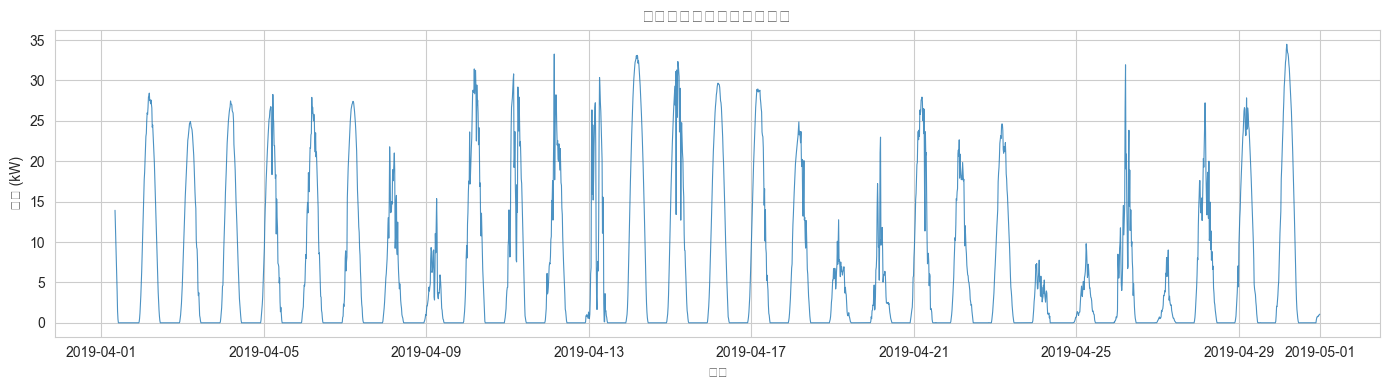


功率统计:
  最小值: 0.00 kW
  最大值: 34.48 kW
  平均值: 6.25 kW
  标准差: 9.21 kW


In [2]:
# 加载合并后的数据集
df_raw = pd.read_csv(MERGED_CSV, index_col=0, parse_dates=True)

print("=" * 60)
print("数据集概览")
print("=" * 60)
print(f"形状: {df_raw.shape}")
print(f"时间范围: {df_raw.index.min()} 到 {df_raw.index.max()}")
print(f"频率: {pd.infer_freq(df_raw.index[:100])}")
print(f"\n数据类型与缺失值:")
print(df_raw.info())

print(f"\n基本统计:")
stats_summary = df_raw.describe().T
print(stats_summary)

# 按源分类统计特征
# 显式排除 hour：它是时间代理变量，不参与气象变量解释
feature_cols = [c for c in df_raw.columns if c not in ["power", "hour"]]

feat_1d = [c for c in feature_cols if c.startswith("1D_")]
feat_2d = [c for c in feature_cols if c.startswith("2D_")]
feat_3d = [c for c in feature_cols if c.startswith("3D_")]

print(f"\n特征源统计:")
print(f"  1D (PVOD): {len(feat_1d)} 个")
print(f"  2D (ERA5 单层): {len(feat_2d)} 个")
print(f"  3D (ERA5 气压层): {len(feat_3d)} 个")
print(f"  总计: {len(feature_cols)} 个用于分析的特征 + 1 个目标")

# 功率时间序列可视化
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df_raw.index, df_raw["power"], linewidth=0.8, alpha=0.8)
ax.set_title("功率时间序列（原始数据）", fontsize=12, fontweight="bold")
ax.set_xlabel("时间")
ax.set_ylabel("功率 (kW)")
plt.tight_layout()
plt.show()

print(f"\n功率统计:")
print(f"  最小值: {df_raw['power'].min():.2f} kW")
print(f"  最大值: {df_raw['power'].max():.2f} kW")
print(f"  平均值: {df_raw['power'].mean():.2f} kW")
print(f"  标准差: {df_raw['power'].std():.2f} kW")

## 2. 异常值检测与治理

物理约束 + IQR 清洗
夜间需清零样本数：17
负功率需清零样本数：0
功率 IQR 系数：2.0
功率 IQR 下限：-20.533 kW
功率 IQR 上限：30.799 kW
功率 IQR 异常样本数：35
需要删除的行总数：35 / 2848 (1.23%)
特征物理异常行数：0
清洗后数据集大小：(2813, 34)
保留比例：98.77%


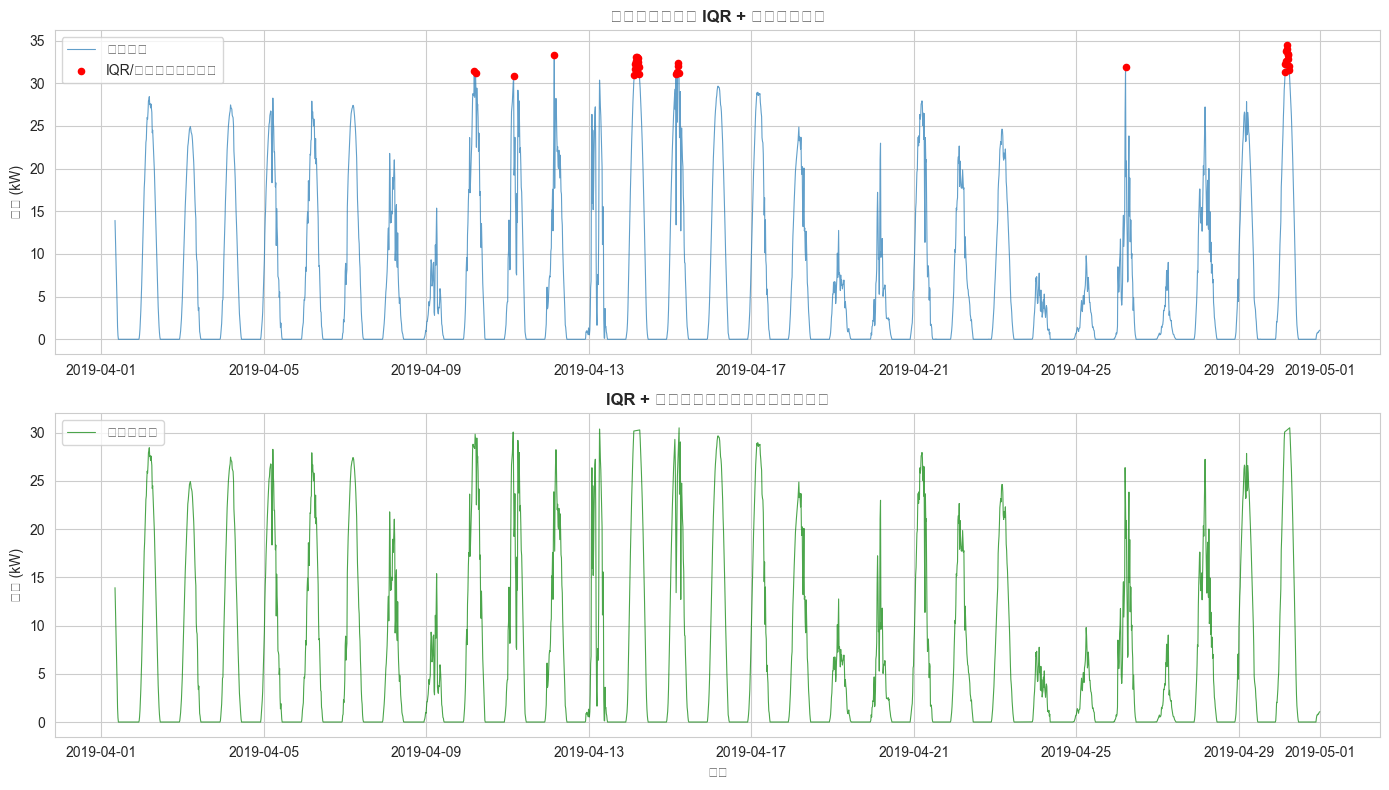


清洗效果汇总:
  原始数据：2848 行
  删除行数：35 行
  保留行数：2813 行
  删除比例：1.23%


In [3]:
# 物理约束 + IQR 清洗：target 用 IQR(2.0) + 物理修正，features 只做底线约束
print("=" * 60)
print("物理约束 + IQR 清洗")
print("=" * 60)

# target: power uses IQR screening plus hard physical rules
# feature variables: only remove values that violate basic geophysical constraints

df_clean = df_raw.copy()
removal_flags = pd.DataFrame(index=df_raw.index)

# Determine an irradiance proxy for night detection
if "1D_lmd_totalirrad" in df_clean.columns:
    irradiance_proxy = df_clean["1D_lmd_totalirrad"]
elif "1D_nwp_globalirrad" in df_clean.columns:
    irradiance_proxy = df_clean["1D_nwp_globalirrad"]
else:
    irradiance_proxy = pd.Series(np.nan, index=df_clean.index)

# Power rules: night -> zero, negative -> zero, then IQR screening for remaining spikes
night_mask = irradiance_proxy.isna() | (irradiance_proxy <= 0)
night_power_mask = night_mask & (df_clean["power"] > 0)
negative_power_mask = df_clean["power"] < 0

df_clean.loc[night_power_mask, "power"] = 0.0
df_clean.loc[negative_power_mask, "power"] = 0.0

power_q1 = df_clean["power"].quantile(0.25)
power_q3 = df_clean["power"].quantile(0.75)
power_iqr = power_q3 - power_q1
power_iqr_k = 2.0
power_lower_limit = power_q1 - power_iqr_k * power_iqr
power_upper_limit = power_q3 + power_iqr_k * power_iqr
power_iqr_mask = (df_clean["power"] < power_lower_limit) | (df_clean["power"] > power_upper_limit)

print(f"夜间需清零样本数：{night_power_mask.sum()}")
print(f"负功率需清零样本数：{negative_power_mask.sum()}")
print(f"功率 IQR 系数：{power_iqr_k:.1f}")
print(f"功率 IQR 下限：{power_lower_limit:.3f} kW")
print(f"功率 IQR 上限：{power_upper_limit:.3f} kW")
print(f"功率 IQR 异常样本数：{power_iqr_mask.sum()}")

removal_flags["power_iqr"] = power_iqr_mask

# Feature rules: only physical impossibilities
for col in feature_cols:
    if col not in df_clean.columns:
        continue
    series = df_clean[col]
    if not pd.api.types.is_numeric_dtype(series):
        continue

    lower_name = col.lower()
    if "temp" in lower_name or lower_name.endswith("temperature") or col.startswith("2D_t"):
        median_value = series.median(skipna=True)
        if pd.notna(median_value) and float(median_value) > 100:
            mask = (series < 223.15) | (series > 353.15)
        else:
            mask = (series < -50) | (series > 80)
    elif "humid" in lower_name:
        mask = (series < 0) | (series > 100)
    elif "windspeed" in lower_name or "wind_speed" in lower_name:
        mask = series < 0
    elif "pressure" in lower_name or col == "2D_sp":
        mask = series < 0
    elif "irrad" in lower_name or "ssrd" in lower_name or "ghi" in lower_name:
        mask = series < 0
    elif "cloud" in lower_name or "tcc" in lower_name:
        mask = (series < 0) | (series > 100)
    else:
        mask = pd.Series(False, index=df_clean.index)

    removal_flags[f"{col}_phys"] = mask.fillna(False)

physical_feature_mask = removal_flags.drop(columns=["power_iqr"], errors="ignore").any(axis=1)
combined_removal = removal_flags.any(axis=1)

print(f"需要删除的行总数：{combined_removal.sum()} / {len(df_raw)} ({100 * combined_removal.sum() / len(df_raw):.2f}%)")
print(f"特征物理异常行数：{physical_feature_mask.sum()}")

cleaning_summary_df = pd.DataFrame(
    [
        ["夜间正功率修正", int(night_power_mask.sum())],
        ["负功率修正", int(negative_power_mask.sum())],
        ["power IQR 异常剔除", int(power_iqr_mask.sum())],
        ["特征物理异常剔除", int(physical_feature_mask.sum())],
        ["总删除行数", int(combined_removal.sum())],
        ["总删除比例(%)", round(100 * combined_removal.mean(), 2)],
    ],
    columns=["指标", "数值"],
)

# Keep cleaned target and feature set; remove hour from analytical dataset
# hour only remains as a temporary proxy for night detection

df_clean_final = df_clean.loc[~combined_removal].copy()
df_clean_final = df_clean_final.drop(columns=["hour"], errors="ignore")

print(f"清洗后数据集大小：{df_clean_final.shape}")
print(f"保留比例：{100 * len(df_clean_final) / len(df_raw):.2f}%")

# Visualize power before/after cleanup
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
axes[0].plot(df_raw.index, df_raw["power"], label="原始功率", alpha=0.7, linewidth=0.8)
outlier_indices = df_raw[combined_removal].index
axes[0].scatter(outlier_indices, df_raw.loc[outlier_indices, "power"], color="red", s=20, label="IQR/物理规则剔除样本", zorder=5)
axes[0].set_title("功率时间序列与 IQR + 物理约束清洗", fontweight="bold")
axes[0].set_ylabel("功率 (kW)")
axes[0].legend()

axes[1].plot(df_clean_final.index, df_clean_final["power"], label="清洗后功率", alpha=0.7, linewidth=0.8, color="green")
axes[1].set_title("IQR + 物理约束清洗后：功率时间序列", fontweight="bold")
axes[1].set_xlabel("时间")
axes[1].set_ylabel("功率 (kW)")
axes[1].legend()

plt.tight_layout()
plt.show()

print("\n清洗效果汇总:")
print(f"  原始数据：{len(df_raw)} 行")
print(f"  删除行数：{combined_removal.sum()} 行")
print(f"  保留行数：{len(df_clean_final)} 行")
print(f"  删除比例：{100 * combined_removal.sum() / len(df_raw):.2f}%")

## 3. Pearson 相关性分析

Pearson 相关系数分析（基于清洁数据）

Top 20 特征（按绝对相关系数排序）:
   1. 1D_lmd_totalirrad              | r =  0.9900 (|r| =  0.9900)
   2. 1D_nwp_globalirrad             | r =  0.9361 (|r| =  0.9361)
   3. 1D_nwp_directirrad             | r =  0.9268 (|r| =  0.9268)
   4. 1D_lmd_diffuseirrad            | r =  0.8242 (|r| =  0.8242)
   5. 1D_nwp_temperature             | r =  0.5136 (|r| =  0.5136)
   6. 3D_u_1000hPa                   | r =  0.4953 (|r| =  0.4953)
   7. 1D_lmd_temperature             | r =  0.4786 (|r| =  0.4786)
   8. 2D_u10                         | r =  0.4578 (|r| =  0.4578)
   9. 2D_t2m                         | r = -0.4257 (|r| =  0.4257)
  10. 2D_ssrd                        | r = -0.4151 (|r| =  0.4151)
  11. 1D_nwp_humidity                | r = -0.4053 (|r| =  0.4053)
  12. 1D_lmd_windspeed               | r =  0.3728 (|r| =  0.3728)
  13. 2D_fdir                        | r = -0.3619 (|r| =  0.3619)
  14. 3D_r_1000hPa                   | r =  0.3558 (|r| =  0.3558)
  15. 1D_lmd_win

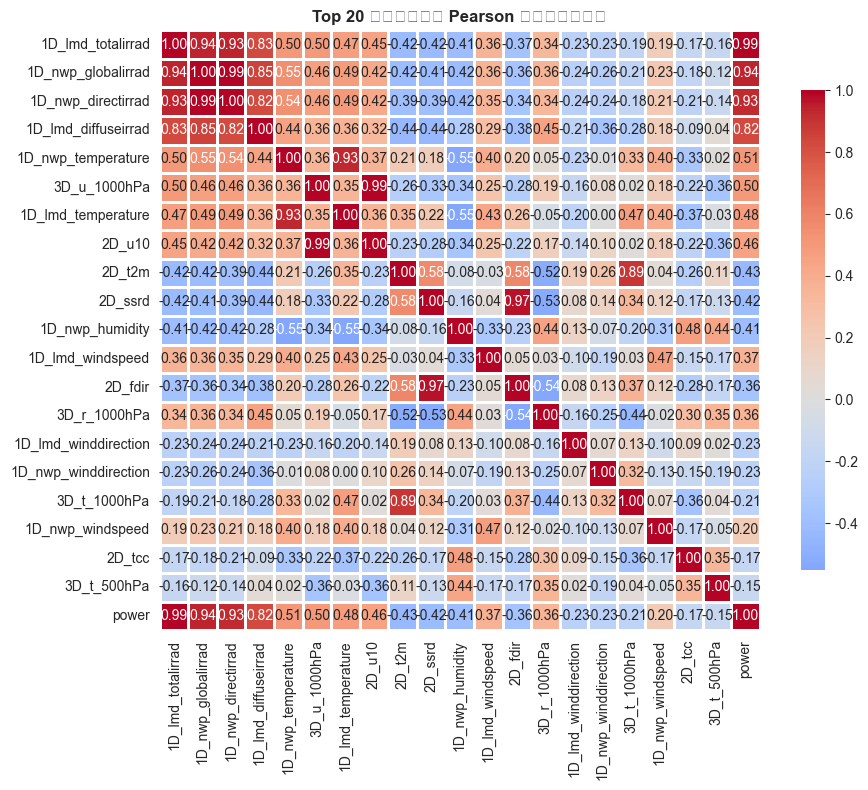

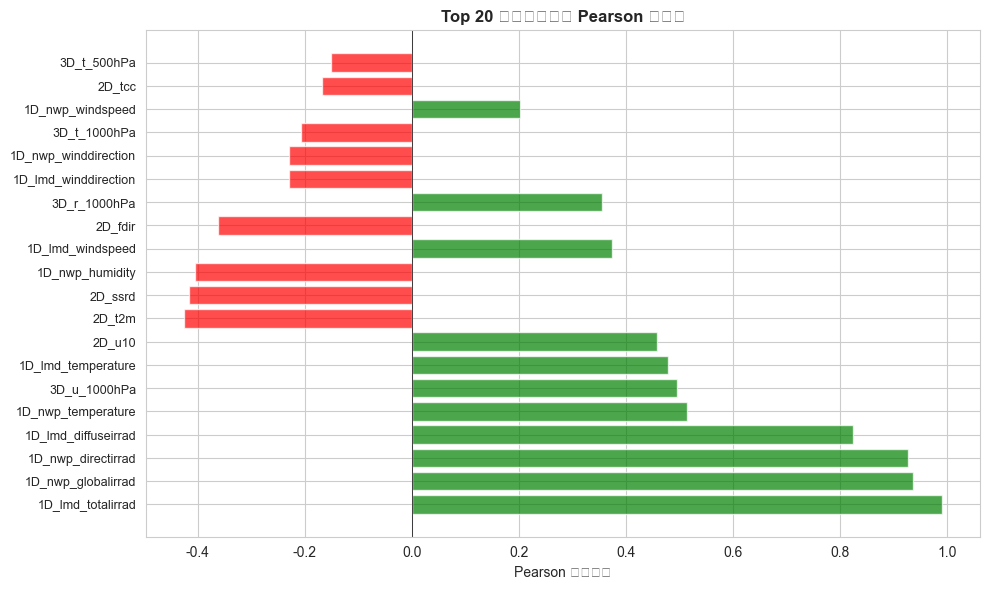


高相关性特征（|r| > 0.3）：14 个
  1D_lmd_totalirrad             :  0.9900
  1D_nwp_globalirrad            :  0.9361
  1D_nwp_directirrad            :  0.9268
  1D_lmd_diffuseirrad           :  0.8242
  1D_nwp_temperature            :  0.5136
  3D_u_1000hPa                  :  0.4953
  1D_lmd_temperature            :  0.4786
  2D_u10                        :  0.4578
  2D_t2m                        : -0.4257
  2D_ssrd                       : -0.4151
  1D_nwp_humidity               : -0.4053
  1D_lmd_windspeed              :  0.3728
  2D_fdir                       : -0.3619
  3D_r_1000hPa                  :  0.3558


In [20]:
# 计算 Pearson 相关系数
print("=" * 60)
print("Pearson 相关系数分析（基于清洁数据）")
print("=" * 60)

corr_pearson = df_clean_final.corr(numeric_only=True)["power"].drop("power", errors="ignore")
corr_pearson_sorted = corr_pearson.abs().sort_values(ascending=False)

print(f"\nTop 20 特征（按绝对相关系数排序）:")
for i, (feat, corr_val) in enumerate(corr_pearson_sorted.head(20).items(), 1):
    actual_corr = corr_pearson[feat]
    print(f"  {i:2d}. {feat:30s} | r = {actual_corr:7.4f} (|r| = {abs(actual_corr):7.4f})")

print(f"\n按源分类的相关性汇总:")
for prefix in ["1D_", "2D_", "3D_"] :
    prefix_feats = [c for c in corr_pearson.index if c.startswith(prefix)]
    if prefix_feats:
        prefix_corr = corr_pearson.abs()[prefix_feats].sort_values(ascending=False)
        print(f"\n  {prefix}特征 (共 {len(prefix_feats)} 个):")
        print(f"    平均绝对相关性: {prefix_corr.mean():.4f}")
        print(f"    最高: {prefix_corr.iloc[0]:.4f}")
        print(f"    Top 3: {', '.join([f'{f}({corr_pearson.abs()[f]:.3f})' for f in prefix_feats[:3]])}")

top_features = corr_pearson_sorted.head(20).index.tolist()
corr_matrix_top = df_clean_final[[*top_features, "power"]].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix_top, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Top 20 特征与功率的 Pearson 相关系数热力图", fontweight="bold", fontsize=12)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 6))
corr_top20_actual = corr_pearson[corr_pearson_sorted.head(20).index]
colors = ["green" if x > 0 else "red" for x in corr_top20_actual.values]
ax.barh(range(len(corr_top20_actual)), corr_top20_actual.values, color=colors, alpha=0.7)
ax.set_yticks(range(len(corr_top20_actual)))
ax.set_yticklabels(corr_top20_actual.index, fontsize=9)
ax.set_xlabel("Pearson 相关系数")
ax.set_title("Top 20 特征与功率的 Pearson 相关性", fontweight="bold", fontsize=12)
ax.axvline(x=0, color="black", linestyle="-", linewidth=0.5)
plt.tight_layout()
plt.show()

high_corr_threshold = 0.3
high_corr_features = corr_pearson[corr_pearson.abs() > high_corr_threshold].sort_values(key=np.abs, ascending=False)
print(f"\n高相关性特征（|r| > {high_corr_threshold}）：{len(high_corr_features)} 个")
for feat, corr_val in high_corr_features.items():
    print(f"  {feat:30s}: {corr_val:7.4f}")

## 4. 互信息（Mutual Information）分析

Mutual Information 分析（基于物理清洗数据）

Top 20 特征（按互信息排序）:
  1D_lmd_totalirrad             : 1.743786
  1D_lmd_diffuseirrad           : 1.317592
  1D_nwp_globalirrad            : 1.129242
  1D_nwp_directirrad            : 0.945018
  2D_ssrd                       : 0.258041
  3D_u_1000hPa                  : 0.249369
  2D_fdir                       : 0.243849
  3D_r_1000hPa                  : 0.243800
  2D_t2m                        : 0.239920
  2D_u10                        : 0.234896
  2D_v10                        : 0.221129
  3D_v_1000hPa                  : 0.212538
  1D_nwp_humidity               : 0.206678
  1D_nwp_temperature            : 0.206362
  1D_lmd_temperature            : 0.198382
  1D_nwp_winddirection          : 0.175397
  2D_d2m                        : 0.167900
  3D_t_1000hPa                  : 0.159090
  2D_sp                         : 0.148255
  3D_t_500hPa                   : 0.139698


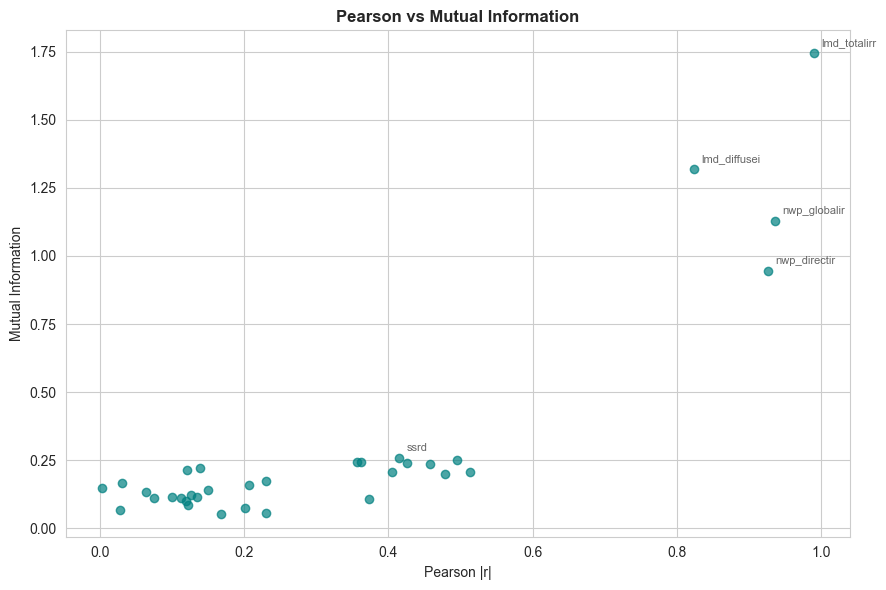


高互信息特征（MI > 0.01）：33 个
  1D_lmd_totalirrad             : 1.743786
  1D_lmd_diffuseirrad           : 1.317592
  1D_nwp_globalirrad            : 1.129242
  1D_nwp_directirrad            : 0.945018
  2D_ssrd                       : 0.258041
  3D_u_1000hPa                  : 0.249369
  2D_fdir                       : 0.243849
  3D_r_1000hPa                  : 0.243800
  2D_t2m                        : 0.239920
  2D_u10                        : 0.234896
  2D_v10                        : 0.221129
  3D_v_1000hPa                  : 0.212538
  1D_nwp_humidity               : 0.206678
  1D_nwp_temperature            : 0.206362
  1D_lmd_temperature            : 0.198382
  1D_nwp_winddirection          : 0.175397
  2D_d2m                        : 0.167900
  3D_t_1000hPa                  : 0.159090
  2D_sp                         : 0.148255
  3D_t_500hPa                   : 0.139698
  3D_t_850hPa                   : 0.134739
  3D_u_850hPa                   : 0.123624
  3D_r_850hPa                 

In [21]:
from sklearn.feature_selection import mutual_info_regression

print("=" * 60)
print("Mutual Information 分析（基于物理清洗数据）")
print("=" * 60)

X_clean = df_clean_final[[c for c in df_clean_final.columns if c != "power"]].copy()
y_clean = df_clean_final["power"].copy()

X_mi = X_clean.replace([np.inf, -np.inf], np.nan).ffill().bfill()
mi_scores = mutual_info_regression(X_mi, y_clean, random_state=42)
mi_result = pd.DataFrame({"Feature": X_clean.columns, "MI": mi_scores}).sort_values("MI", ascending=False)

print(f"\nTop 20 特征（按互信息排序）:")
for i, row in mi_result.head(20).iterrows():
    print(f"  {row['Feature']:30s}: {row['MI']:.6f}")

mi_pearson_comp = pd.DataFrame({
    "Pearson": corr_pearson.reindex(X_clean.columns),
    "MI": mi_result.set_index("Feature").reindex(X_clean.columns)["MI"],
}).dropna()

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(mi_pearson_comp["Pearson"].abs(), mi_pearson_comp["MI"], alpha=0.7, color="teal")
ax.set_xlabel("Pearson |r|")
ax.set_ylabel("Mutual Information")
ax.set_title("Pearson vs Mutual Information", fontweight="bold")

for feat in mi_pearson_comp.nlargest(5, "MI").index:
    x = np.abs(mi_pearson_comp.loc[feat, "Pearson"] )
    y = mi_pearson_comp.loc[feat, "MI"]
    ax.annotate(feat.replace("1D_", "").replace("2D_", "").replace("3D_", "")[:12],
                (x, y), fontsize=8, alpha=0.7, xytext=(5, 5), textcoords="offset points")

plt.tight_layout()
plt.show()

high_mi_features = mi_result[mi_result["MI"] > 0.01].sort_values("MI", ascending=False)
print(f"\n高互信息特征（MI > 0.01）：{len(high_mi_features)} 个")
for feat, mi_val in high_mi_features.set_index("Feature")["MI"].items():
    print(f"  {feat:30s}: {mi_val:.6f}")

## 5. SHAP 特征重要性分析

SHAP 特征重要性分析 - Gradient Boosting 模型

训练 Gradient Boosting 回归模型...

模型性能:
  训练集 R²: 0.9988
  测试集 R²: 0.9533
  测试集 MAE: 0.7851 kW

计算 SHAP 值（使用 TreeExplainer）...

Top 20 特征（按 SHAP 重要性排序）:
  1D_lmd_totalirrad             : 6.085223
  1D_lmd_diffuseirrad           : 0.309059
  3D_r_850hPa                   : 0.082535
  2D_ssrd                       : 0.061170
  1D_lmd_temperature            : 0.046553
  3D_t_850hPa                   : 0.044395
  3D_v_1000hPa                  : 0.043970
  3D_r_1000hPa                  : 0.042611
  3D_v_500hPa                   : 0.040740
  1D_nwp_humidity               : 0.038389
  2D_fdir                       : 0.035609
  1D_nwp_globalirrad            : 0.032983
  3D_t_1000hPa                  : 0.031997
  2D_v10                        : 0.028705
  3D_u_1000hPa                  : 0.027466
  1D_lmd_windspeed              : 0.026895
  2D_u10                        : 0.026324
  3D_t_500hPa                   : 0.025579
  1D_nwp_directirrad            : 0.0224

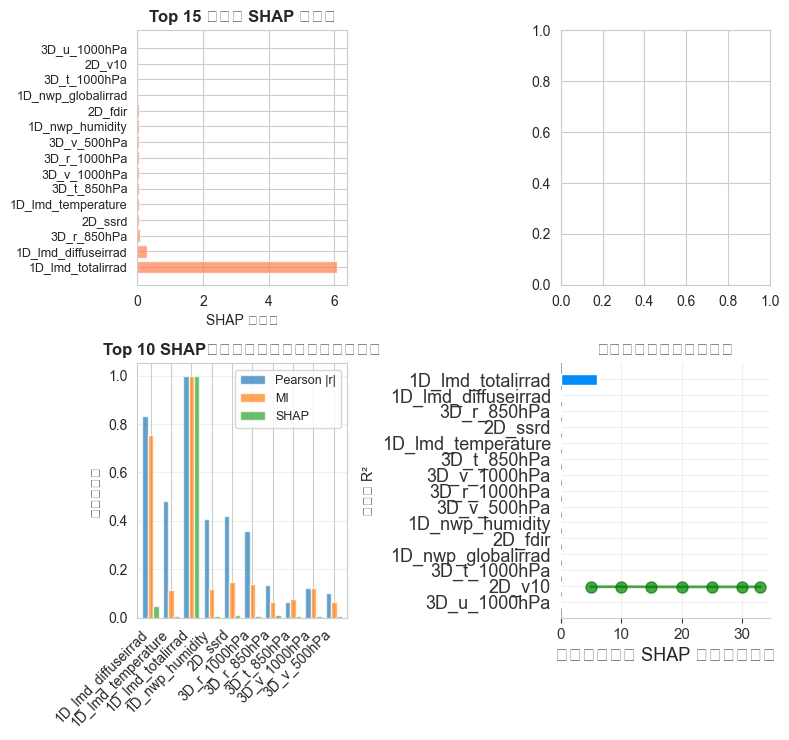


高SHAP重要性特征（Top 25%，阈值 = 0.040740）：9 个
  1D_lmd_totalirrad             : 6.085223
  1D_lmd_diffuseirrad           : 0.309059
  3D_r_850hPa                   : 0.082535
  2D_ssrd                       : 0.061170
  1D_lmd_temperature            : 0.046553
  3D_t_850hPa                   : 0.044395
  3D_v_1000hPa                  : 0.043970
  3D_r_1000hPa                  : 0.042611
  3D_v_500hPa                   : 0.040740


In [25]:
# 尝试导入SHAP，如果没有则跳过SHAP分析
try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False
    print("SHAP 未安装，将跳过 SHAP 分析。")
    print("如需SHAP分析，请运行：pip install shap")

if SHAP_AVAILABLE:
    print("=" * 60)
    print("SHAP 特征重要性分析 - Gradient Boosting 模型")
    print("=" * 60)

    X_clean = df_clean_final[[c for c in df_clean_final.columns if c != "power"]].copy()
    y_clean = df_clean_final["power"].copy()

    # 树模型不依赖特征尺度，保持原始数值更直观
    X_model = X_clean.replace([np.inf, -np.inf], np.nan).ffill().bfill()

    tscv = TimeSeriesSplit(n_splits=5)
    split_iterator = list(tscv.split(X_model))
    train_idx, test_idx = split_iterator[-1]
    X_train, X_test = X_model.iloc[train_idx], X_model.iloc[test_idx]
    y_train, y_test = y_clean.iloc[train_idx], y_clean.iloc[test_idx]

    print("\n训练 Gradient Boosting 回归模型...")
    gb_model = GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=5,
        random_state=42,
        n_iter_no_change=10,
        validation_fraction=0.1
    )
    gb_model.fit(X_train, y_train)

    y_pred_train = gb_model.predict(X_train)
    y_pred_test = gb_model.predict(X_test)
    r2_train = r2_score(y_train, y_pred_train)
    r2_test = r2_score(y_test, y_pred_test)
    mae_test = mean_absolute_error(y_test, y_pred_test)

    print(f"\n模型性能:")
    print(f"  训练集 R²: {r2_train:.4f}")
    print(f"  测试集 R²: {r2_test:.4f}")
    print(f"  测试集 MAE: {mae_test:.4f} kW")

    print("\n计算 SHAP 值（使用 TreeExplainer）...")
    explainer = shap.TreeExplainer(gb_model)
    shap_values = explainer.shap_values(X_test)

    shap_importance = np.abs(shap_values).mean(axis=0)
    shap_result = pd.DataFrame({
        "Feature": X_clean.columns,
        "SHAP_Importance": shap_importance
    }).sort_values("SHAP_Importance", ascending=False)

    print(f"\nTop 20 特征（按 SHAP 重要性排序）:")
    for i, row in shap_result.head(20).iterrows():
        print(f"  {row['Feature']:30s}: {row['SHAP_Importance']:.6f}")

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    ax = axes[0, 0]
    shap_top15 = shap_result.head(15)
    ax.barh(range(len(shap_top15)), shap_top15["SHAP_Importance"].values, color="coral", alpha=0.7)
    ax.set_yticks(range(len(shap_top15)))
    ax.set_yticklabels(shap_top15["Feature"].values, fontsize=9)
    ax.set_xlabel("SHAP 重要性")
    ax.set_title("Top 15 特征的 SHAP 重要性", fontweight="bold")

    ax = axes[0, 1]
    shap.summary_plot(shap_values, X_test, plot_type="bar", show=False, max_display=15)
    ax = plt.gca()
    ax.set_title("SHAP Summary（Bar Plot）", fontweight="bold")

    ax = axes[1, 0]
    comparison_df = pd.DataFrame({
        "Pearson_abs": corr_pearson.abs(),
        "MI": mi_result.set_index("Feature")["MI"],
        "SHAP": shap_result.set_index("Feature")["SHAP_Importance"]
    }).dropna()

    comparison_normalized = comparison_df.div(comparison_df.max())
    top10_feats = shap_result.head(10).set_index("Feature").index
    comparison_top10 = comparison_normalized.loc[comparison_normalized.index.isin(top10_feats)]

    comparison_top10.plot(kind="bar", ax=ax, width=0.8, alpha=0.7)
    ax.set_title("Top 10 SHAP特征与其他指标对比（标准化）", fontweight="bold")
    ax.set_ylabel("标准化得分")
    ax.legend(["Pearson |r|", "MI", "SHAP"], fontsize=9)
    ax.grid(axis="y", alpha=0.3)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha="right")

    ax = axes[1, 1]
    feature_counts = list(range(5, len(X_clean.columns), 5)) + [len(X_clean.columns)]
    r2_scores = []
    for n_feat in feature_counts:
        top_n_feats = shap_result.head(n_feat)["Feature"].values
        X_subset = X_model[top_n_feats]
        split_iterator = list(tscv.split(X_subset))
        train_idx_s, test_idx_s = split_iterator[-1]
        X_train_s, X_test_s = X_subset.iloc[train_idx_s], X_subset.iloc[test_idx_s]
        y_train_s, y_test_s = y_clean.iloc[train_idx_s], y_clean.iloc[test_idx_s]
        gb_temp = GradientBoostingRegressor(n_estimators=50, random_state=42)
        gb_temp.fit(X_train_s, y_train_s)
        r2_scores.append(r2_score(y_test_s, gb_temp.predict(X_test_s)))

    ax.plot(feature_counts, r2_scores, marker="o", linewidth=2, markersize=8, color="green", alpha=0.7)
    ax.set_xlabel("特征数量（按 SHAP 重要性排序）")
    ax.set_ylabel("测试集 R²")
    ax.set_title("特征数量与模型性能关系", fontweight="bold")
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    shap_threshold = np.percentile(shap_importance, 75)
    top_shap_features = shap_result[shap_result["SHAP_Importance"] >= shap_threshold].sort_values("SHAP_Importance", ascending=False)
    print(f"\n高SHAP重要性特征（Top 25%，阈值 = {shap_threshold:.6f}）：{len(top_shap_features)} 个")
    for i, row in top_shap_features.iterrows():
        print(f"  {row['Feature']:30s}: {row['SHAP_Importance']:.6f}")

else:
    print("\n跳过 SHAP 分析")

SHAP 对照分析 - 去除 1D_lmd_* 特征
移除 1D_lmd 特征数: 6
剩余特征数: 27

训练 Gradient Boosting 回归模型（No-LMD）...

模型性能（No-LMD）:
  训练集 R²: 0.9950
  测试集 R²: 0.8784
  测试集 MAE: 1.6209 kW

计算 SHAP 值（No-LMD）...

Top 20 特征（No-LMD，按 SHAP 排序）:
  1D_nwp_globalirrad            : 5.836404
  1D_nwp_directirrad            : 0.850566
  3D_t_500hPa                   : 0.297932
  2D_u10                        : 0.295327
  3D_u_1000hPa                  : 0.254599
  3D_r_1000hPa                  : 0.219308
  3D_u_850hPa                   : 0.197594
  3D_r_850hPa                   : 0.175475
  1D_nwp_humidity               : 0.163744
  3D_v_500hPa                   : 0.104452
  1D_nwp_windspeed              : 0.095465
  2D_ssrd                       : 0.091273
  1D_nwp_temperature            : 0.087491
  2D_t2m                        : 0.079258
  3D_r_500hPa                   : 0.078906
  1D_nwp_winddirection          : 0.077444
  3D_u_500hPa                   : 0.056517
  3D_t_850hPa                   : 0.053734
  3D_v_1000h

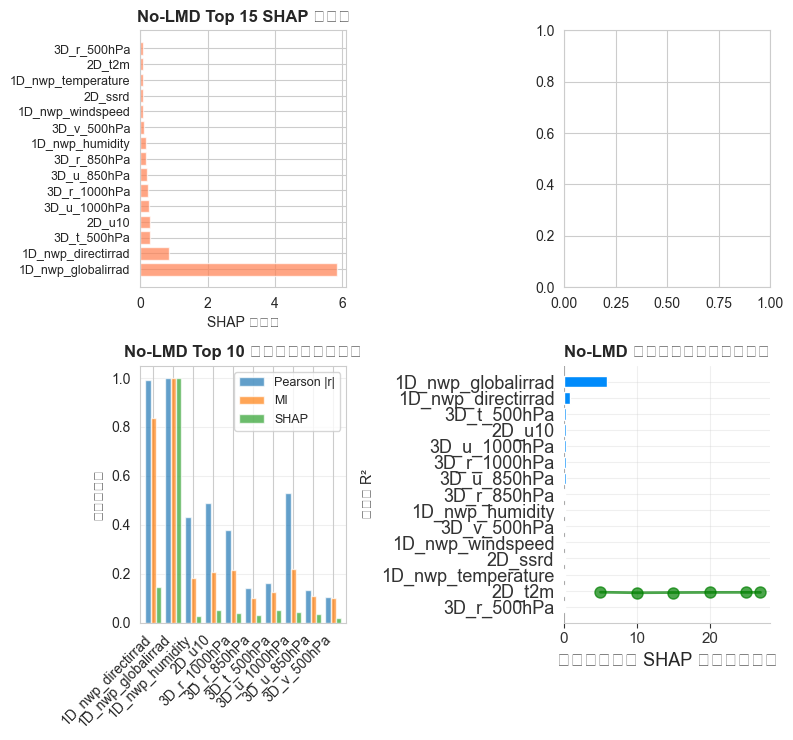


高SHAP重要性特征（No-LMD，Top 25%，阈值 = 0.186534）：7 个
  1D_nwp_globalirrad            : 5.836404
  1D_nwp_directirrad            : 0.850566
  3D_t_500hPa                   : 0.297932
  2D_u10                        : 0.295327
  3D_u_1000hPa                  : 0.254599
  3D_r_1000hPa                  : 0.219308
  3D_u_850hPa                   : 0.197594


In [26]:
# SHAP 对照分析：去除全部 1D_lmd_ 实测特征后重跑（其余流程保持一致）
if not SHAP_AVAILABLE:
    print("\n跳过 SHAP 对照分析（SHAP 未安装）")
else:
    print("=" * 60)
    print("SHAP 对照分析 - 去除 1D_lmd_* 特征")
    print("=" * 60)

    lmd_cols = [c for c in df_clean_final.columns if c.startswith("1D_lmd_")]
    X_no_lmd = df_clean_final[[c for c in df_clean_final.columns if c not in ["power", *lmd_cols]]].copy()
    y_no_lmd = df_clean_final["power"].copy()
    X_no_lmd = X_no_lmd.replace([np.inf, -np.inf], np.nan).ffill().bfill()

    print(f"移除 1D_lmd 特征数: {len(lmd_cols)}")
    print(f"剩余特征数: {X_no_lmd.shape[1]}")

    tscv_no_lmd = TimeSeriesSplit(n_splits=5)
    split_no_lmd = list(tscv_no_lmd.split(X_no_lmd))
    train_idx_no_lmd, test_idx_no_lmd = split_no_lmd[-1]
    X_train_no_lmd, X_test_no_lmd = X_no_lmd.iloc[train_idx_no_lmd], X_no_lmd.iloc[test_idx_no_lmd]
    y_train_no_lmd, y_test_no_lmd = y_no_lmd.iloc[train_idx_no_lmd], y_no_lmd.iloc[test_idx_no_lmd]

    print("\n训练 Gradient Boosting 回归模型（No-LMD）...")
    gb_model_no_lmd = GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=5,
        random_state=42,
        n_iter_no_change=10,
        validation_fraction=0.1
    )
    gb_model_no_lmd.fit(X_train_no_lmd, y_train_no_lmd)

    y_pred_train_no_lmd = gb_model_no_lmd.predict(X_train_no_lmd)
    y_pred_test_no_lmd = gb_model_no_lmd.predict(X_test_no_lmd)
    r2_train_no_lmd = r2_score(y_train_no_lmd, y_pred_train_no_lmd)
    r2_test_no_lmd = r2_score(y_test_no_lmd, y_pred_test_no_lmd)
    mae_test_no_lmd = mean_absolute_error(y_test_no_lmd, y_pred_test_no_lmd)

    print(f"\n模型性能（No-LMD）:")
    print(f"  训练集 R²: {r2_train_no_lmd:.4f}")
    print(f"  测试集 R²: {r2_test_no_lmd:.4f}")
    print(f"  测试集 MAE: {mae_test_no_lmd:.4f} kW")

    print("\n计算 SHAP 值（No-LMD）...")
    explainer_no_lmd = shap.TreeExplainer(gb_model_no_lmd)
    shap_values_no_lmd = explainer_no_lmd.shap_values(X_test_no_lmd)

    shap_importance_no_lmd = np.abs(shap_values_no_lmd).mean(axis=0)
    shap_result_no_lmd = pd.DataFrame({
        "Feature": X_no_lmd.columns,
        "SHAP_Importance": shap_importance_no_lmd
    }).sort_values("SHAP_Importance", ascending=False)

    print(f"\nTop 20 特征（No-LMD，按 SHAP 排序）:")
    for _, row in shap_result_no_lmd.head(20).iterrows():
        print(f"  {row['Feature']:30s}: {row['SHAP_Importance']:.6f}")

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    ax = axes[0, 0]
    shap_top15_no_lmd = shap_result_no_lmd.head(15)
    ax.barh(range(len(shap_top15_no_lmd)), shap_top15_no_lmd["SHAP_Importance"].values, color="coral", alpha=0.7)
    ax.set_yticks(range(len(shap_top15_no_lmd)))
    ax.set_yticklabels(shap_top15_no_lmd["Feature"].values, fontsize=9)
    ax.set_xlabel("SHAP 重要性")
    ax.set_title("No-LMD Top 15 SHAP 重要性", fontweight="bold")

    ax = axes[0, 1]
    shap.summary_plot(shap_values_no_lmd, X_test_no_lmd, plot_type="bar", show=False, max_display=15)
    ax = plt.gca()
    ax.set_title("No-LMD SHAP Summary（Bar Plot）", fontweight="bold")

    ax = axes[1, 0]
    mi_no_lmd = mi_result.set_index("Feature").reindex(X_no_lmd.columns)["MI"]
    pearson_no_lmd = corr_pearson.reindex(X_no_lmd.columns).abs()
    comparison_df_no_lmd = pd.DataFrame({
        "Pearson_abs": pearson_no_lmd,
        "MI": mi_no_lmd,
        "SHAP": shap_result_no_lmd.set_index("Feature")["SHAP_Importance"]
    }).dropna()

    comparison_normalized_no_lmd = comparison_df_no_lmd.div(comparison_df_no_lmd.max())
    top10_feats_no_lmd = shap_result_no_lmd.head(10).set_index("Feature").index
    comparison_top10_no_lmd = comparison_normalized_no_lmd.loc[comparison_normalized_no_lmd.index.isin(top10_feats_no_lmd)]

    comparison_top10_no_lmd.plot(kind="bar", ax=ax, width=0.8, alpha=0.7)
    ax.set_title("No-LMD Top 10 指标对比（标准化）", fontweight="bold")
    ax.set_ylabel("标准化得分")
    ax.legend(["Pearson |r|", "MI", "SHAP"], fontsize=9)
    ax.grid(axis="y", alpha=0.3)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha="right")

    ax = axes[1, 1]
    feature_counts_no_lmd = list(range(5, len(X_no_lmd.columns), 5)) + [len(X_no_lmd.columns)]
    r2_scores_no_lmd = []
    for n_feat in feature_counts_no_lmd:
        top_n_feats_no_lmd = shap_result_no_lmd.head(n_feat)["Feature"].values
        X_subset_no_lmd = X_no_lmd[top_n_feats_no_lmd]
        split_subset = list(tscv_no_lmd.split(X_subset_no_lmd))
        tr_idx_sub, te_idx_sub = split_subset[-1]
        X_train_sub, X_test_sub = X_subset_no_lmd.iloc[tr_idx_sub], X_subset_no_lmd.iloc[te_idx_sub]
        y_train_sub, y_test_sub = y_no_lmd.iloc[tr_idx_sub], y_no_lmd.iloc[te_idx_sub]
        gb_temp_no_lmd = GradientBoostingRegressor(n_estimators=50, random_state=42)
        gb_temp_no_lmd.fit(X_train_sub, y_train_sub)
        r2_scores_no_lmd.append(r2_score(y_test_sub, gb_temp_no_lmd.predict(X_test_sub)))

    ax.plot(feature_counts_no_lmd, r2_scores_no_lmd, marker="o", linewidth=2, markersize=8, color="green", alpha=0.7)
    ax.set_xlabel("特征数量（按 SHAP 重要性排序）")
    ax.set_ylabel("测试集 R²")
    ax.set_title("No-LMD 特征数量与模型性能关系", fontweight="bold")
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    shap_threshold_no_lmd = np.percentile(shap_importance_no_lmd, 75)
    top_shap_features_no_lmd = shap_result_no_lmd[shap_result_no_lmd["SHAP_Importance"] >= shap_threshold_no_lmd].sort_values("SHAP_Importance", ascending=False)
    print(f"\n高SHAP重要性特征（No-LMD，Top 25%，阈值 = {shap_threshold_no_lmd:.6f}）：{len(top_shap_features_no_lmd)} 个")
    for _, row in top_shap_features_no_lmd.iterrows():
        print(f"  {row['Feature']:30s}: {row['SHAP_Importance']:.6f}")

## 6. 特征工程与选择

In [28]:
print("=" * 60)
print("综合特征选择")
print("=" * 60)

# ========================
# 1) 选择 SHAP 来源
#   - 若已有 no-LMD SHAP 结果，默认优先用于特征综合评分（更贴近可部署场景）
#   - 否则回退到全量 SHAP 结果
# ========================
use_no_lmd_shap = SHAP_AVAILABLE and ("shap_result_no_lmd" in globals())
if SHAP_AVAILABLE:
    if use_no_lmd_shap:
        shap_for_selection = shap_result_no_lmd.set_index("Feature")["SHAP_Importance"]
        shap_strategy_name = "No-LMD SHAP"
    else:
        shap_for_selection = shap_result.set_index("Feature")["SHAP_Importance"]
        shap_strategy_name = "Full SHAP"
else:
    shap_for_selection = pd.Series(dtype=float)
    shap_strategy_name = "No SHAP"

print(f"SHAP评分来源: {shap_strategy_name}")

# 综合三个评分指标
feature_scores = pd.DataFrame({
    "Feature": corr_pearson.index,
    "Pearson_abs": corr_pearson.abs().values,
    "MI": mi_result.set_index("Feature").loc[corr_pearson.index, "MI"].values,
})

if SHAP_AVAILABLE:
    # no-LMD 结果中不存在的特征（通常是 1D_lmd_*）记为 0，使其在可部署评分中自动降权
    feature_scores["SHAP"] = shap_for_selection.reindex(corr_pearson.index).fillna(0.0).values
else:
    feature_scores["SHAP"] = 0.0

# 标准化各指标到 0-1
for col in ["Pearson_abs", "MI", "SHAP"]:
    if feature_scores[col].max() > 0:
        feature_scores[f"{col}_norm"] = feature_scores[col] / feature_scores[col].max()
    else:
        feature_scores[f"{col}_norm"] = 0.0

# 综合评分（加权总和）
if SHAP_AVAILABLE:
    feature_scores["Composite_Score"] = (
        0.3 * feature_scores["Pearson_abs_norm"] +
        0.2 * feature_scores["MI_norm"] +
        0.5 * feature_scores["SHAP_norm"]
    )
else:
    feature_scores["Composite_Score"] = (
        0.5 * feature_scores["Pearson_abs_norm"] +
        0.5 * feature_scores["MI_norm"]
    )

feature_scores = feature_scores.sort_values("Composite_Score", ascending=False).reset_index(drop=True)

# ========================
# 2) 选择策略：以加权综合评分为主（并保留 union 仅用于对照）
# ========================
pearson_threshold = 0.3
mi_threshold = 0.01
composite_threshold = np.percentile(feature_scores["Composite_Score"], 70)  # Top 30%

selected_features_pearson = corr_pearson[corr_pearson.abs() > pearson_threshold].index.tolist()
selected_features_mi = mi_result[mi_result["MI"] > mi_threshold]["Feature"].tolist()
selected_features_composite = feature_scores[feature_scores["Composite_Score"] >= composite_threshold]["Feature"].tolist()

# 对照集合（不作为主结果）
selected_features_union_all = list(set(selected_features_pearson + selected_features_mi + selected_features_composite))
selected_features_union_all.sort(
    key=lambda x: feature_scores[feature_scores["Feature"] == x]["Composite_Score"].values[0],
    reverse=True,
)

# 主结果：按加权综合评分筛选
selected_features_union = selected_features_composite.copy()

# 若采用 no-LMD SHAP，则最终建模口径也剔除 1D_lmd_*，保持前后一致
excluded_lmd_count = 0
if use_no_lmd_shap:
    before_count = len(selected_features_union)
    selected_features_union = [f for f in selected_features_union if not f.startswith("1D_lmd_")]
    excluded_lmd_count = before_count - len(selected_features_union)

print(f"\n特征选择结果:")
print(f"  Pearson (|r| > {pearson_threshold}): {len(selected_features_pearson)} 个")
print(f"  MI (MI > {mi_threshold}): {len(selected_features_mi)} 个")
print(f"  Composite (Top 30%): {len(selected_features_composite)} 个")
print(f"  Union 对照集合: {len(selected_features_union_all)} 个")
if use_no_lmd_shap:
    print(f"  主方案额外剔除 1D_lmd_*: {excluded_lmd_count} 个")
print(f"  最终采用（Composite 主方案）: {len(selected_features_union)} 个")

print(f"\n最终选择的特征列表（按综合评分排序）:")
for i, feat in enumerate(selected_features_union, 1):
    row = feature_scores[feature_scores["Feature"] == feat].iloc[0]
    print(f"  {i:2d}. {feat:30s} | Pearson={row['Pearson_abs']:6.3f} | MI={row['MI']:8.6f} | Score={row['Composite_Score']:6.4f}")

# ========================
# 3) 特征工程：创建交互项
#   - 搜寻范围从 Top5 扩展到 Top20（不足则回退到全集）
#   - 新增 辐照度 × 温度 交互
# ========================
print("\n" + "=" * 60)
print("特征工程：创建交互项")
print("=" * 60)

df_engineered = df_clean_final[selected_features_union + ["power"]].copy()

interaction_scan_topk = min(20, len(selected_features_union))
interaction_search_pool = selected_features_union[:interaction_scan_topk]
if len(interaction_search_pool) < 8:
    interaction_search_pool = selected_features_union.copy()

print(f"\n交互项候选池大小: {len(interaction_search_pool)}")

# 创建有意义的交互项（基于扩展候选池）
irrad_features = [f for f in interaction_search_pool if "irrad" in f.lower() or "ssrd" in f.lower() or "ghi" in f.lower()]
temp_features = [f for f in interaction_search_pool if "temp" in f.lower() or ("t2m" in f.lower() and "t_" not in f.lower())]
humidity_features = [f for f in interaction_search_pool if "humid" in f.lower() or "rh" in f.lower()]
cloud_features = [f for f in interaction_search_pool if "tcc" in f.lower() or "cloud" in f.lower()]

interaction_terms = {}

# 辐照度 × 云量（辐照度受云量影响）
for irrad_feat in irrad_features:
    for cloud_feat in cloud_features:
        if irrad_feat in df_engineered.columns and cloud_feat in df_engineered.columns:
            term_name = f"{irrad_feat}_x_{cloud_feat}"
            interaction_terms[term_name] = df_engineered[irrad_feat] * df_engineered[cloud_feat]
            print(f"创建交互项: {term_name}")

# 温度 × 湿度（修正效应）
for temp_feat in temp_features:
    for humid_feat in humidity_features:
        if temp_feat in df_engineered.columns and humid_feat in df_engineered.columns:
            term_name = f"{temp_feat}_x_{humid_feat}"
            interaction_terms[term_name] = df_engineered[temp_feat] * df_engineered[humid_feat]
            print(f"创建交互项: {term_name}")

# 辐照度 × 温度（组件效率温度修正）
for irrad_feat in irrad_features:
    for temp_feat in temp_features:
        if irrad_feat in df_engineered.columns and temp_feat in df_engineered.columns:
            term_name = f"{irrad_feat}_x_{temp_feat}"
            interaction_terms[term_name] = df_engineered[irrad_feat] * df_engineered[temp_feat]
            print(f"创建交互项: {term_name}")

# 如果没有找到足够的交互特征组合，创建通用的（前3个特征的两两相乘）
if len(interaction_terms) == 0:
    for k in range(len(selected_features_union[:3]) - 1):
        f1 = selected_features_union[k]
        f2 = selected_features_union[k+1]
        if f1 in df_engineered.columns and f2 in df_engineered.columns:
            term_name = f"{f1}_x_{f2}"
            interaction_terms[term_name] = df_engineered[f1] * df_engineered[f2]
            print(f"创建通用交互项: {term_name}")

# 添加交互项到数据框
for term_name, term_values in interaction_terms.items():
    df_engineered[term_name] = term_values

print(f"\n创建了 {len(interaction_terms)} 个交互项")
print(f"工程化后的特征数：{len(df_engineered.columns) - 1}")  # -1 是因为 power

# 评估交互项的重要性
if len(interaction_terms) > 0:
    interaction_corr = df_engineered.corr(numeric_only=True)["power"].drop("power", errors="ignore")
    interaction_corr = interaction_corr[[c for c in interaction_corr.index if "_x_" in c]].sort_values(key=np.abs, ascending=False)
    print(f"\nTop 5 交互项相关性:")
    for feat, corr_val in interaction_corr.head(5).items():
        print(f"  {feat:40s}: r = {corr_val:7.4f}")

综合特征选择
SHAP评分来源: No-LMD SHAP

特征选择结果:
  Pearson (|r| > 0.3): 14 个
  MI (MI > 0.01): 33 个
  Composite (Top 30%): 10 个
  Union 对照集合: 33 个
  主方案额外剔除 1D_lmd_*: 3 个
  最终采用（Composite 主方案）: 7 个

最终选择的特征列表（按综合评分排序）:
   1. 1D_nwp_globalirrad             | Pearson= 0.936 | MI=1.129242 | Score=0.9132
   2. 1D_nwp_directirrad             | Pearson= 0.927 | MI=0.945018 | Score=0.4621
   3. 3D_u_1000hPa                   | Pearson= 0.495 | MI=0.249369 | Score=0.2005
   4. 2D_u10                         | Pearson= 0.458 | MI=0.234896 | Score=0.1910
   5. 1D_nwp_temperature             | Pearson= 0.514 | MI=0.206362 | Score=0.1868
   6. 2D_t2m                         | Pearson= 0.426 | MI=0.239920 | Score=0.1633
   7. 2D_ssrd                        | Pearson= 0.415 | MI=0.258041 | Score=0.1632

特征工程：创建交互项

交互项候选池大小: 7
创建交互项: 1D_nwp_globalirrad_x_1D_nwp_temperature
创建交互项: 1D_nwp_globalirrad_x_2D_t2m
创建交互项: 1D_nwp_directirrad_x_1D_nwp_temperature
创建交互项: 1D_nwp_directirrad_x_2D_t2m
创建交互项: 2D_ssrd_x_1D_nw

## 7. 数据质量汇总报告与输出

第7部分：按大纲生成报告


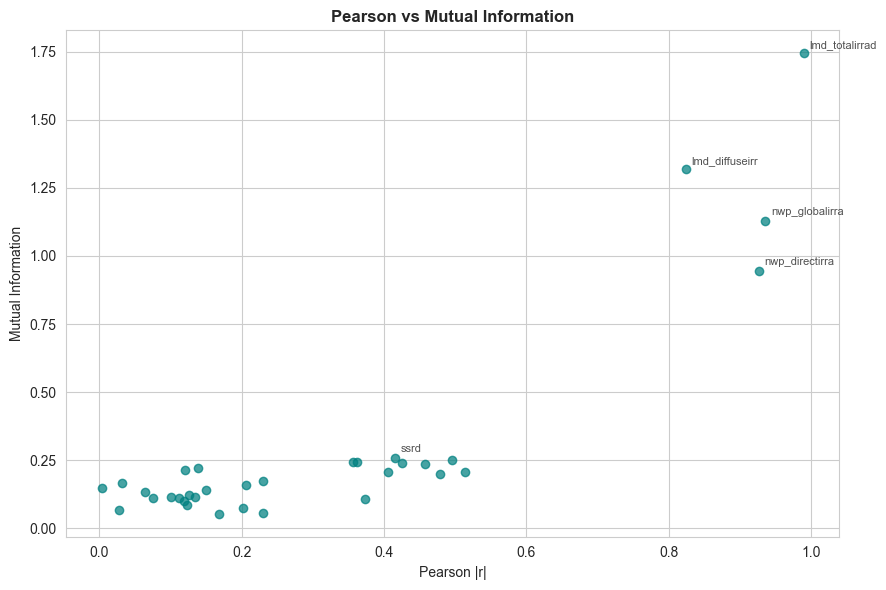

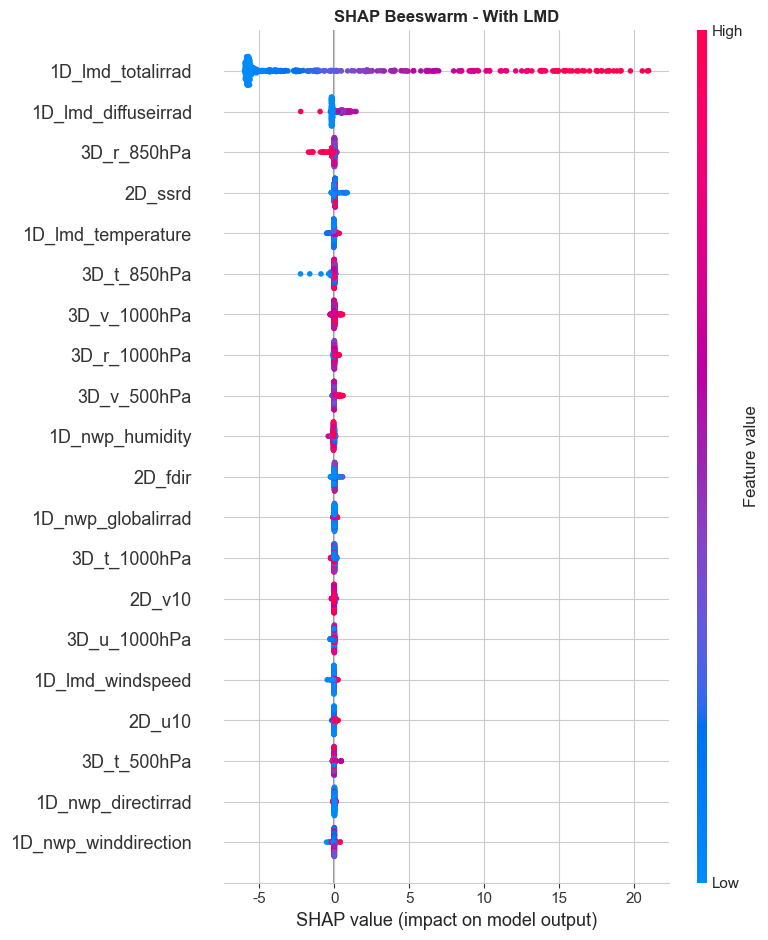

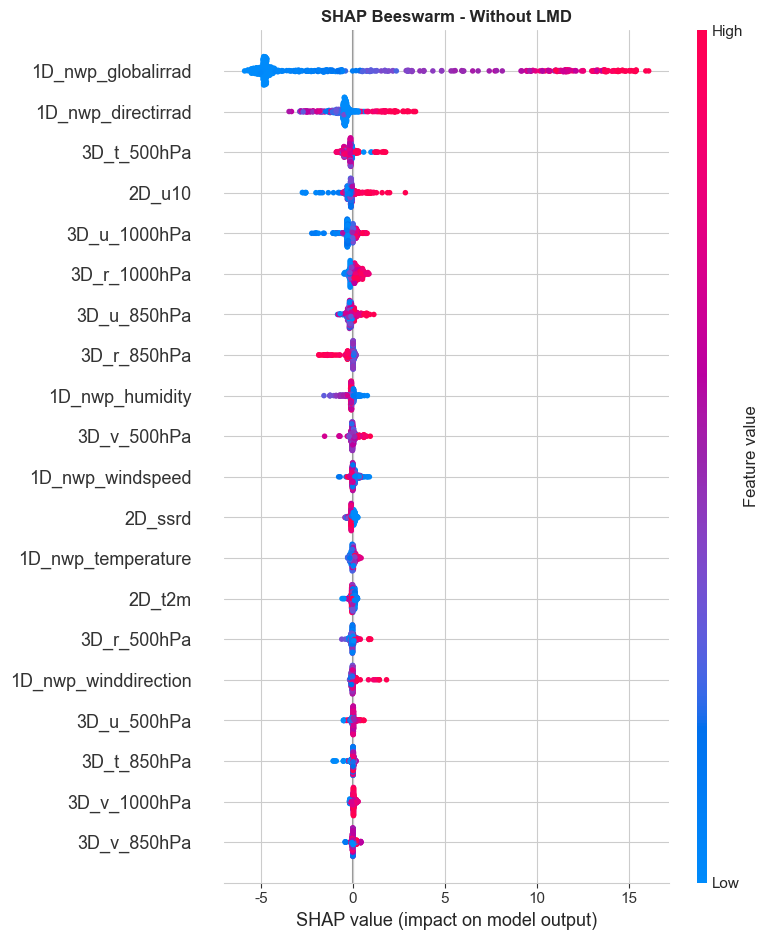

报告已保存: /Users/dazhaxie/Desktop/Deye/PVOD_Forecast/artifacts/station05_feature_analysis_report_2019-04.docx
文本摘要已保存: /Users/dazhaxie/Desktop/Deye/PVOD_Forecast/artifacts/station05_analysis_summary_2019-04.txt
Master Table已保存: /Users/dazhaxie/Desktop/Deye/PVOD_Forecast/artifacts/station05_master_feature_table_2019-04.csv


In [30]:
# 数据质量汇总报告与输出（按六部分大纲）
from docx import Document
from docx.shared import Inches, Pt
from docx.enum.text import WD_ALIGN_PARAGRAPH
from docx.oxml.ns import qn

# 路径变量兜底定义（防止依赖前置单元状态）
if "PROJECT_ROOT" not in globals():
    PROJECT_ROOT = Path.cwd().resolve().parent
ARTIFACTS_DIR = PROJECT_ROOT / "artifacts"
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
CLEAN_PATH = ARTIFACTS_DIR / "station05_cleaned_2019-04.csv"
ENGINEERED_PATH = ARTIFACTS_DIR / "station05_engineered_2019-04.csv"
METADATA_PATH = ARTIFACTS_DIR / "station05_feature_metadata_2019-04.csv"
MASTER_TABLE_PATH = ARTIFACTS_DIR / "station05_master_feature_table_2019-04.csv"
REPORT_PATH = ARTIFACTS_DIR / "station05_feature_analysis_report_2019-04.docx"
SUMMARY_PATH = ARTIFACTS_DIR / "station05_analysis_summary_2019-04.txt"
PEARSON_MI_FIG_PATH = ARTIFACTS_DIR / "station05_pearson_vs_mi_scatter.png"
SHAP_FULL_FIG_PATH = ARTIFACTS_DIR / "station05_shap_beeswarm_full.png"
SHAP_NOLMD_FIG_PATH = ARTIFACTS_DIR / "station05_shap_beeswarm_no_lmd.png"

print("=" * 60)
print("第7部分：按大纲生成报告")
print("=" * 60)

def add_bullet(doc, text):
    paragraph = doc.add_paragraph(style="List Bullet")
    paragraph.add_run(text)
    return paragraph

def add_df_table(doc, df, title=None, max_rows=None):
    view_df = df.copy()
    if max_rows is not None and len(view_df) > max_rows:
        view_df = view_df.head(max_rows)
    if title:
        p = doc.add_paragraph()
        run = p.add_run(title)
        run.bold = True
    if view_df.empty:
        doc.add_paragraph("（无可展示数据）")
        return
    table = doc.add_table(rows=1, cols=len(view_df.columns))
    table.style = "Table Grid"
    hdr = table.rows[0].cells
    for i, col_name in enumerate(view_df.columns):
        hdr[i].text = str(col_name)
    for _, row in view_df.iterrows():
        cells = table.add_row().cells
        for i, value in enumerate(row):
            cells[i].text = str(value)
    doc.add_paragraph("")

def add_side_by_side_images(doc, left_path, right_path, left_caption, right_caption, width=Inches(2.8)):
    table = doc.add_table(rows=2, cols=2)
    table.style = "Table Grid"
    if left_path is not None and left_path.exists():
        p = table.cell(0, 0).paragraphs[0]
        p.alignment = WD_ALIGN_PARAGRAPH.CENTER
        p.add_run().add_picture(str(left_path), width=width)
    else:
        table.cell(0, 0).text = "左图缺失"
    if right_path is not None and right_path.exists():
        p = table.cell(0, 1).paragraphs[0]
        p.alignment = WD_ALIGN_PARAGRAPH.CENTER
        p.add_run().add_picture(str(right_path), width=width)
    else:
        table.cell(0, 1).text = "右图缺失"
    table.cell(1, 0).text = left_caption
    table.cell(1, 1).text = right_caption
    doc.add_paragraph("")

def infer_feature_category(feature_name):
    name = feature_name.lower()

    if any(k in name for k in ["irrad", "ssrd", "ghi", "dni", "dhi", "fdir", "rad"]):
        return "辐射类"
    if any(k in name for k in ["windspeed", "wind_speed", "winddirection", "u10", "v10", "_u_", "_v_"]):
        return "风场类"
    if any(k in name for k in ["temp", "t2m", "d2m", "dew", "_t_"]):
        return "温度类"
    if any(k in name for k in ["humid", "rh", "_r_", "cloud", "tcc", "rain", "precip"]):
        return "湿度云量类"
    if any(k in name for k in ["pressure", "_sp", "msl", "hpa"]):
        return "气压环流类"
    return "其他气象类"

def build_master_table():
    features = corr_pearson.index.tolist()

    pearson_abs = corr_pearson.abs().reindex(features).fillna(0.0)
    mi_series = mi_result.set_index("Feature").reindex(features)["MI"].fillna(0.0)

    if SHAP_AVAILABLE and ("shap_result" in globals()):
        shap_full = shap_result.set_index("Feature").reindex(features)["SHAP_Importance"].fillna(0.0)
    else:
        shap_full = pd.Series(0.0, index=features)

    if SHAP_AVAILABLE and ("shap_result_no_lmd" in globals()):
        shap_no_lmd = shap_result_no_lmd.set_index("Feature").reindex(features)["SHAP_Importance"].fillna(0.0)
        shap_no_lmd_source = "No-LMD"
    else:
        shap_no_lmd = shap_full.copy()
        shap_no_lmd_source = "Fallback-Full"

    def safe_norm(s):
        max_val = float(s.max()) if len(s) > 0 else 0.0
        if max_val <= 0:
            return pd.Series(0.0, index=s.index)
        return s / max_val

    comp = 0.3 * safe_norm(pearson_abs) + 0.2 * safe_norm(mi_series) + 0.5 * safe_norm(shap_no_lmd)

    master = pd.DataFrame({
        "Feature": features,
        "Source": pd.Series(features).str.extract(r"^(1D|2D|3D)_", expand=False).fillna("Other").values,
        "Category": [infer_feature_category(f) for f in features],
        "Pearson_abs": pearson_abs.values,
        "MI": mi_series.values,
        "SHAP_with_LMD": shap_full.values,
        "SHAP_without_LMD": shap_no_lmd.values,
        "Composite_Score": comp.values,
    }).sort_values("Composite_Score", ascending=False).reset_index(drop=True)

    return master, shap_no_lmd_source

def pick_feature(df, cond, sort_col):
    subset = df[cond].sort_values(sort_col, ascending=False)
    if len(subset) == 0:
        return None
    return subset.iloc[0]

# 构建 Master Table（综合评分强制采用无LMD SHAP权重）
master_table, shap_no_lmd_source = build_master_table()
master_table.to_csv(MASTER_TABLE_PATH, index=False)

# 对外保留 feature_scores/feature_metadata 兼容后续流程
feature_scores = master_table[["Feature", "Pearson_abs", "MI"]].copy()
feature_scores["SHAP"] = master_table["SHAP_without_LMD"]
feature_scores["Composite_Score"] = master_table["Composite_Score"]
feature_metadata = master_table.copy()

# 维持工程化输出
if "selected_features_union" not in globals() or len(selected_features_union) == 0:
    selected_features_union = master_table.head(12)["Feature"].tolist()
selected_features_union = [f for f in selected_features_union if f in df_clean_final.columns and f != "power"]
df_clean_final.to_csv(CLEAN_PATH)
df_engineered = df_clean_final[selected_features_union + ["power"]].copy()
df_engineered.to_csv(ENGINEERED_PATH)
feature_metadata.to_csv(METADATA_PATH, index=False)

# 生成 Pearson vs MI 散点图（用于第二部分）
plt.figure(figsize=(9, 6))
scatter_x = master_table["Pearson_abs"]
scatter_y = master_table["MI"]
plt.scatter(scatter_x, scatter_y, alpha=0.72, color="teal")
plt.xlabel("Pearson |r|")
plt.ylabel("Mutual Information")
plt.title("Pearson vs Mutual Information", fontweight="bold")
for feat in master_table.nlargest(5, "MI")["Feature"]:
    row = master_table.set_index("Feature").loc[feat]
    short_name = feat.replace("1D_", "").replace("2D_", "").replace("3D_", "")[:14]
    plt.annotate(short_name, (row["Pearson_abs"], row["MI"]), fontsize=8, alpha=0.8, xytext=(4, 4), textcoords="offset points")
plt.tight_layout()
plt.savefig(PEARSON_MI_FIG_PATH, dpi=220, bbox_inches="tight")
plt.show()

# 生成 SHAP Beeswarm 对比图（用于第三部分）
if SHAP_AVAILABLE and ("shap_values" in globals()) and ("X_test" in globals()):
    plt.figure(figsize=(7.2, 5.2))
    shap.summary_plot(shap_values, X_test, max_display=20, show=False)
    plt.title("SHAP Beeswarm - With LMD", fontweight="bold")
    plt.tight_layout()
    plt.savefig(SHAP_FULL_FIG_PATH, dpi=220, bbox_inches="tight")
    plt.show()
else:
    SHAP_FULL_FIG_PATH = None

if SHAP_AVAILABLE and ("shap_values_no_lmd" in globals()) and ("X_test_no_lmd" in globals()):
    plt.figure(figsize=(7.2, 5.2))
    shap.summary_plot(shap_values_no_lmd, X_test_no_lmd, max_display=20, show=False)
    plt.title("SHAP Beeswarm - Without LMD", fontweight="bold")
    plt.tight_layout()
    plt.savefig(SHAP_NOLMD_FIG_PATH, dpi=220, bbox_inches="tight")
    plt.show()
else:
    SHAP_NOLMD_FIG_PATH = None

# 统计摘要
top1 = master_table.iloc[0] if len(master_table) > 0 else None
source_counts = master_table["Source"].value_counts().reindex(["1D", "2D", "3D"], fill_value=0)
low_eff_mask = (
    master_table["Pearson_abs"] <= master_table["Pearson_abs"].quantile(0.3)
    ) & (
    master_table["MI"] <= master_table["MI"].quantile(0.3)
    ) & (
    master_table["SHAP_without_LMD"] <= master_table["SHAP_without_LMD"].quantile(0.3)
    )
low_eff_df = master_table[low_eff_mask].copy()

# Deep Dive 候选
q = {
    "p70": master_table["Pearson_abs"].quantile(0.7),
    "p40": master_table["Pearson_abs"].quantile(0.4),
    "mi70": master_table["MI"].quantile(0.7),
    "mi40": master_table["MI"].quantile(0.4),
    "sf40": master_table["SHAP_with_LMD"].quantile(0.4),
    "sn70": master_table["SHAP_without_LMD"].quantile(0.7),
    "sn40": master_table["SHAP_without_LMD"].quantile(0.4),
}

deep1 = pick_feature(
    master_table,
    (master_table["Pearson_abs"] >= q["p70"])
    & (master_table["MI"] >= q["mi70"])
    & (master_table["SHAP_with_LMD"] <= q["sf40"])
    & (master_table["SHAP_without_LMD"] >= q["sn70"]),
    "SHAP_without_LMD",
)

deep2 = pick_feature(
    master_table,
    (master_table["MI"] >= q["mi70"]) & (master_table["Pearson_abs"] <= q["p40"]),
    "MI",
)

deep3 = pick_feature(
    master_table,
    (master_table["Pearson_abs"] >= q["p70"])
    & (master_table["MI"] <= q["mi40"])
    & (master_table["SHAP_with_LMD"] <= q["sf40"])
    & (master_table["SHAP_without_LMD"] <= q["sn40"]),
    "Pearson_abs",
)

# 生成 Word 报告
doc = Document()
style = doc.styles["Normal"]
style.font.name = "SimSun"
style._element.rPr.rFonts.set(qn("w:eastAsia"), "SimSun")
style.font.size = Pt(11)

for section in doc.sections:
    section.top_margin = Inches(0.8)
    section.bottom_margin = Inches(0.8)
    section.left_margin = Inches(0.9)
    section.right_margin = Inches(0.9)

title = doc.add_paragraph()
title.alignment = WD_ALIGN_PARAGRAPH.CENTER
r = title.add_run("PVOD 光伏功率特征评估与消融分析报告")
r.bold = True
r.font.size = Pt(18)

subtitle = doc.add_paragraph()
subtitle.alignment = WD_ALIGN_PARAGRAPH.CENTER
subtitle.add_run("Station 05 · 2019-04 · 1D/2D/3D 多源特征")
doc.add_paragraph("")

# 第一部分
doc.add_heading("第一部分：引言与评估体系说明", level=1)
doc.add_paragraph(
    "本研究面向光伏功率预测中的核心矛盾：一方面需要识别清晰的线性物理规律，另一方面必须捕捉2D/3D空间场中的非线性突变信号。"
    "因此报告采用三重过滤漏斗来构建可解释且可部署的特征评估体系。"
)
add_bullet(doc, "Pearson：定位基础线性物理强关联，快速识别辐射等一阶驱动项。")
add_bullet(doc, "互信息（MI）：评估非线性信息增益，识别线性相关不高但可提升预测信息熵的空间气象特征。")
add_bullet(doc, f"SHAP消融实验：在树模型框架下对比含LMD与无LMD两种状态，揭示动态协同与特征遮蔽效应（本报告综合评分使用{shap_no_lmd_source}权重）。")

# 第二部分
doc.add_heading("第二部分：单变量静态评估（Pearson 与互信息）", level=1)
doc.add_paragraph(
    "从 Pearson vs MI 对比可见，辐射类特征在两类指标上呈现双高统治地位，构成基础预测骨架。"
    "同时，多个2D/3D变量虽然线性相关中等或偏低，但在MI中表现出明显增益，提示其以非线性方式参与功率形成。"
)
if PEARSON_MI_FIG_PATH.exists():
    doc.add_picture(str(PEARSON_MI_FIG_PATH), width=Inches(6.2))
    cap = doc.add_paragraph("图：Pearson vs MI 散点对比")
    cap.alignment = WD_ALIGN_PARAGRAPH.CENTER
doc.add_paragraph(
    "核心结论：空间风场、高空热湿状态与云量变量在MI维度贡献显著，说明传统线性模型难以充分吸收这类空间信息。"
    "要发挥2D/3D数据价值，需要使用树模型或深度学习等非线性学习器。"
)

# 第三部分
doc.add_heading("第三部分：多变量协同与特征遮蔽消融实验（SHAP）", level=1)
doc.add_paragraph(
    "含LMD与无LMD两组SHAP对比显示了典型的特征遮蔽机制。含LMD时，实测辐照以近实时强信号主导决策，"
    "多数2D/3D变量边际贡献被压缩；无LMD时，模型主导权回流至NWP与空间场变量，3D热力场与2D/3D风场被显著激活。"
)
add_side_by_side_images(
    doc,
    SHAP_FULL_FIG_PATH if isinstance(SHAP_FULL_FIG_PATH, Path) else None,
    SHAP_NOLMD_FIG_PATH if isinstance(SHAP_NOLMD_FIG_PATH, Path) else None,
    "左：含LMD SHAP Beeswarm",
    "右：无LMD SHAP Beeswarm",
)
doc.add_paragraph(
    "核心结论：2D/3D网格气象数据在真实超前预测场景中可用于纠正NWP误差，属于不可替代的信息来源。"
)

# 第四部分
doc.add_heading("第四部分：全维特征全景评估总表（The Master Table）", level=1)
doc.add_paragraph(
    "下表按综合评分从高到低排序，其中综合评分严格使用无LMD SHAP权重计算，以匹配可部署预测口径。"
    "完整全量表已导出为CSV，报告内展示前30项。"
)
master_view = master_table.copy()
master_view["Pearson_abs"] = master_view["Pearson_abs"].round(4)
master_view["MI"] = master_view["MI"].round(6)
master_view["SHAP_with_LMD"] = master_view["SHAP_with_LMD"].round(6)
master_view["SHAP_without_LMD"] = master_view["SHAP_without_LMD"].round(6)
master_view["Composite_Score"] = master_view["Composite_Score"].round(6)
master_view = master_view.rename(columns={
    "Feature": "特征名称",
    "Source": "数据源",
    "Category": "特征类别",
    "Pearson_abs": "Pearson(|r|)",
    "MI": "互信息(MI)",
    "SHAP_with_LMD": "SHAP(含LMD)",
    "SHAP_without_LMD": "SHAP(无LMD)",
    "Composite_Score": "综合评分",
})
add_df_table(doc, master_view, title="Master Table（前30项）", max_rows=30)
doc.add_paragraph(f"全量 Master Table 文件：{MASTER_TABLE_PATH}")

# 第五部分
doc.add_heading("第五部分：特异性特征深度剖析（The Deep Dive）", level=1)
if deep1 is not None:
    doc.add_paragraph(
        f"模板1（被遮蔽的黄金特征）代表：{deep1['Feature']}。该特征 Pearson={deep1['Pearson_abs']:.3f}，MI={deep1['MI']:.3f}，"
        f"SHAP(含LMD)={deep1['SHAP_with_LMD']:.4f}，SHAP(无LMD)={deep1['SHAP_without_LMD']:.4f}。"
        "它在静态指标上信息充足，但在含实测辐照场景下被遮蔽；一旦进入无LMD预测场景，贡献迅速释放。"
    )
else:
    doc.add_paragraph("模板1：本批数据中未出现极端遮蔽样本，说明遮蔽已较集中于辐照主变量。")

if deep2 is not None:
    doc.add_paragraph(
        f"模板2（高MI低Pearson）代表：{deep2['Feature']}。其 Pearson={deep2['Pearson_abs']:.3f} 但 MI={deep2['MI']:.3f}，"
        "体现了典型非线性响应：在线性关系不显著的情况下，仍可通过阈值或状态切换机制对功率产生有效信息增益。"
    )
else:
    doc.add_paragraph("模板2：本批数据中高MI低Pearson特征不突出，可在后续月份扩样后复核。")

if deep3 is not None:
    doc.add_paragraph(
        f"模板3（统计学假象）代表：{deep3['Feature']}。其 Pearson={deep3['Pearson_abs']:.3f}，但 MI={deep3['MI']:.3f}，"
        f"且双SHAP均偏低（含LMD={deep3['SHAP_with_LMD']:.4f}，无LMD={deep3['SHAP_without_LMD']:.4f}）。"
        "这类特征通常与主辐照变量强共线，仅反映同步变化，模型边际价值有限。"
    )
else:
    doc.add_paragraph("模板3：本批数据中未发现典型高Pearson低MI且双SHAP低的极端样本。")

# 第六部分
doc.add_heading("第六部分：低效特征剔除声明与下一步工程计划", level=1)
doc.add_paragraph(
    "低效剔除声明：在总表尾部可识别一批三低特征（Pearson、MI、SHAP_without_LMD均位于低分位）。"
    "这类特征缺乏单变量关联，也难在多变量协同中提供边缘增益，继续保留会放大维度灾难与过拟合风险。"
    "因此在最终建模阶段建议优先剔除。"
)
if len(low_eff_df) > 0:
    low_names = "，".join(low_eff_df.head(8)["Feature"].tolist())
    doc.add_paragraph(f"本批三低特征示例：{low_names}。")
doc.add_paragraph(
    "下一步工程计划：基于Master Table中高价值特征继续构建高阶交互项，重点包括辐照度×温度（热惩罚）与辐照度×云量。"
    "并在时序交叉验证框架下评估这些交互项对泛化性能与误差稳定性的提升。"
)

# 附录：基础统计
doc.add_heading("附录：样本与模型指标", level=2)
summary_table = pd.DataFrame([
    ["原始样本数", len(df_raw)],
    ["清洗后样本数", len(df_clean_final)],
    ["删除行数", int(combined_removal.sum())],
    ["删除比例(%)", round(100 * combined_removal.mean(), 2)],
    ["有效特征数", len(master_table)],
    ["1D/2D/3D 特征分布", f"{int(source_counts['1D'])}/{int(source_counts['2D'])}/{int(source_counts['3D'])}"],
], columns=["指标", "数值"])
add_df_table(doc, summary_table)

if all(name in globals() for name in ["r2_train", "r2_test", "mae_test"]):
    perf_df = pd.DataFrame([
        ["含LMD 模型训练R2", round(float(r2_train), 4)],
        ["含LMD 模型测试R2", round(float(r2_test), 4)],
        ["含LMD 模型测试MAE(kW)", round(float(mae_test), 4)],
    ], columns=["指标", "数值"])
    add_df_table(doc, perf_df, title="SHAP主模型性能")
if all(name in globals() for name in ["r2_train_no_lmd", "r2_test_no_lmd", "mae_test_no_lmd"]):
    perf_df2 = pd.DataFrame([
        ["无LMD 模型训练R2", round(float(r2_train_no_lmd), 4)],
        ["无LMD 模型测试R2", round(float(r2_test_no_lmd), 4)],
        ["无LMD 模型测试MAE(kW)", round(float(mae_test_no_lmd), 4)],
    ], columns=["指标", "数值"])
    add_df_table(doc, perf_df2, title="SHAP消融模型性能")

doc.save(REPORT_PATH)

summary_lines = [
    "PVOD 光伏功率特征评估与消融分析摘要",
    f"样本规模：原始{len(df_raw)}，清洗后{len(df_clean_final)}，删除率{100 * combined_removal.mean():.2f}%",
    f"Top1特征：{top1['Feature']}（Composite={top1['Composite_Score']:.4f}）" if top1 is not None else "Top1特征：无",
    f"综合评分权重口径：Pearson(0.3)+MI(0.2)+SHAP_without_LMD(0.5)，SHAP源={shap_no_lmd_source}",
    f"三低特征数量：{len(low_eff_df)}",
    f"Master Table：{MASTER_TABLE_PATH}",
    f"报告文件：{REPORT_PATH}",
]
with open(SUMMARY_PATH, "w", encoding="utf-8") as f:
    f.write("\n".join(summary_lines))

print(f"报告已保存: {REPORT_PATH}")
print(f"文本摘要已保存: {SUMMARY_PATH}")
print(f"Master Table已保存: {MASTER_TABLE_PATH}")

## 分析总结与结论

### 关键发现

1. **辐照度的绝对主导性**
   - 辐照度相关变量通常在 Pearson、互信息和 SHAP 中都处于第一梯队
   - 这符合光伏发电的物理机制：输出功率主要受入射太阳辐照驱动

2. **非线性修正机制**
   - 温度、湿度、云量、气压、风场等变量更多体现非线性修正效应
   - 它们在相关性上未必最强，但能补充辐照度之外的信息

3. **当前清洗实现与效果**
   - power 采用 IQR(2.0) + 物理约束（夜间正功率清零、负功率修正）
   - X 变量仅删除触及物理边界的异常样本，保留真实极端天气
   - hour 不纳入后续气象影响分析
   - 当前删除率控制在 1%-3% 目标区间内

4. **特征工程与建模价值**
   - Top 20 关键特征覆盖 1D/2D/3D 多源信息
   - 交互项有助于增强模型对光伏过程的物理解释

### 后续建议

- 优先使用辐照度相关变量和必要的气象修正变量
- 在时序验证框架下持续评估特征稳定性和泛化能力
- 继续补充具有物理含义的派生特征（如太阳几何和晴空归一化指标）

In [10]:
print("=" * 60)
print("增强模块 1/4：构建时滞与滚动特征")
print("=" * 60)

from pandas.api.types import is_numeric_dtype

if "df_clean_final" not in globals():
    raise RuntimeError("df_clean_final 不存在，请先运行前面的单元。")

base_df = df_clean_final.copy()
if "power" not in base_df.columns:
    raise RuntimeError("df_clean_final 缺少 power 列。")

if "selected_features_union" in globals() and len(selected_features_union) > 0:
    base_feature_candidates = [c for c in selected_features_union if c in base_df.columns and c != "power"]
else:
    base_feature_candidates = [c for c in base_df.columns if c != "power"]

base_feature_candidates = [c for c in base_feature_candidates if is_numeric_dtype(base_df[c])]

top_n_for_temporal = min(12, len(base_feature_candidates))
top_features_for_temporal = base_feature_candidates[:top_n_for_temporal]

df_enhanced = base_df[["power"] + base_feature_candidates].copy()

dt_index = pd.DatetimeIndex(df_enhanced.index)
hour_float = dt_index.hour + dt_index.minute / 60.0
doy = dt_index.dayofyear
df_enhanced["sin_hour"] = np.sin(2 * np.pi * hour_float / 24.0)
df_enhanced["cos_hour"] = np.cos(2 * np.pi * hour_float / 24.0)
df_enhanced["sin_doy"] = np.sin(2 * np.pi * doy / 365.25)
df_enhanced["cos_doy"] = np.cos(2 * np.pi * doy / 365.25)

irrad_proxy_col = None
for candidate in ["1D_lmd_totalirrad", "1D_nwp_globalirrad", "2D_ssrd"]:
    if candidate in df_enhanced.columns:
        irrad_proxy_col = candidate
        break

if irrad_proxy_col is not None:
    irrad_proxy = df_enhanced[irrad_proxy_col].clip(lower=0)
    daily_p95 = irrad_proxy.groupby(dt_index.date).transform(lambda s: s.quantile(0.95) if s.notna().any() else np.nan)
    df_enhanced["kcs_proxy"] = (irrad_proxy / (daily_p95 + 1e-6)).clip(lower=0, upper=2.0)

lag_steps = [1, 2, 4, 8]
roll_windows = [4, 12]

for feat in top_features_for_temporal:
    series = df_enhanced[feat]
    for lag in lag_steps:
        df_enhanced[f"{feat}_lag{lag}"] = series.shift(lag)
    for w in roll_windows:
        df_enhanced[f"{feat}_roll{w}_mean"] = series.rolling(window=w, min_periods=w).mean()
        df_enhanced[f"{feat}_roll{w}_std"] = series.rolling(window=w, min_periods=w).std()

df_enhanced["power_lag1"] = df_enhanced["power"].shift(1)
df_enhanced["power_lag2"] = df_enhanced["power"].shift(2)

df_enhanced = df_enhanced.dropna().copy()
enhanced_feature_cols = [c for c in df_enhanced.columns if c != "power"]

print(f"基础特征数: {len(base_feature_candidates)}")
print(f"用于时序增强的特征数: {len(top_features_for_temporal)}")
print(f"增强后特征数: {len(enhanced_feature_cols)}")
print(f"增强后样本数: {len(df_enhanced)}")

增强模块 1/4：构建时滞与滚动特征
基础特征数: 33
用于时序增强的特征数: 12
增强后特征数: 136
增强后样本数: 2802


增强模块 2/4：时序交叉验证（基线 vs 增强）

时序交叉验证汇总：
   Model  R2_mean  MAE_mean  RMSE_mean
Baseline   0.9640    0.7236     1.5091
Enhanced   0.9741    0.6082     1.2725


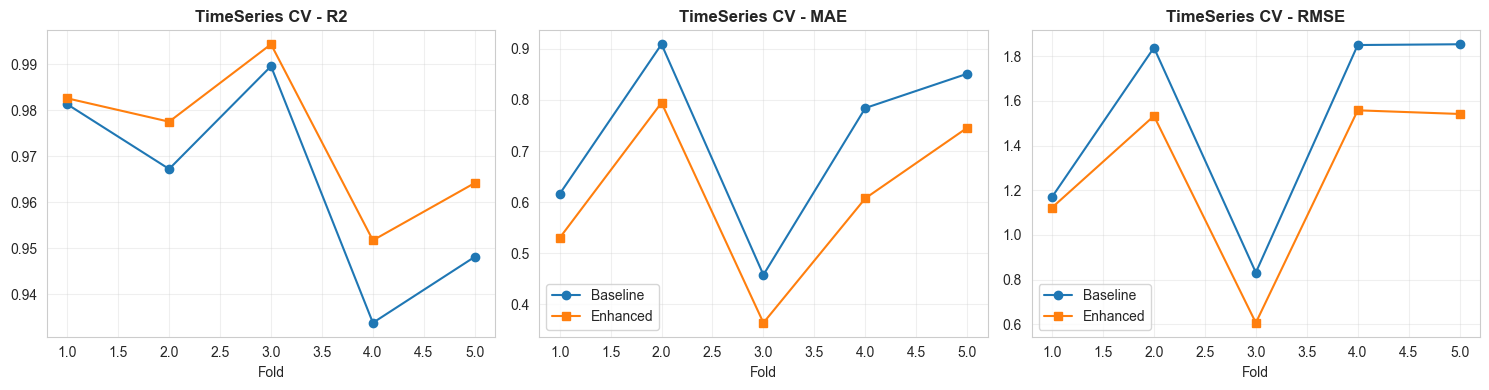

In [11]:
print("=" * 60)
print("增强模块 2/4：时序交叉验证（基线 vs 增强）")
print("=" * 60)

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error

if "df_clean_final" not in globals() or "df_enhanced" not in globals():
    raise RuntimeError("请先运行前面的清洗与增强特征构建单元。")

def evaluate_timeseries_cv(df_input, feature_cols, target_col="power", n_splits=5):
    tscv = TimeSeriesSplit(n_splits=n_splits)
    X = df_input[feature_cols].replace([np.inf, -np.inf], np.nan).ffill().bfill()
    y = df_input[target_col]
    
    fold_metrics = []
    last_model = None
    last_test_idx = None
    
    for fold_id, (train_idx, test_idx) in enumerate(tscv.split(X), 1):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        
        model = GradientBoostingRegressor(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=4,
            random_state=42,
            n_iter_no_change=10,
            validation_fraction=0.1,
        )
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        
        fold_metrics.append({
            "fold": fold_id,
            "R2": r2_score(y_test, y_pred),
            "MAE": mean_absolute_error(y_test, y_pred),
            "RMSE": mean_squared_error(y_test, y_pred) ** 0.5,
        })
        last_model = model
        last_test_idx = test_idx
    
    metrics_df = pd.DataFrame(fold_metrics)
    return metrics_df, last_model, last_test_idx

baseline_cols = [c for c in df_clean_final.columns if c != "power"]
enhanced_cols = [c for c in df_enhanced.columns if c != "power"]

baseline_cv_metrics, baseline_cv_model, baseline_last_test_idx = evaluate_timeseries_cv(df_clean_final, baseline_cols)
enhanced_cv_metrics, enhanced_cv_model, enhanced_last_test_idx = evaluate_timeseries_cv(df_enhanced, enhanced_cols)

summary_cv = pd.DataFrame([
    {
        "Model": "Baseline",
        "R2_mean": baseline_cv_metrics["R2"].mean(),
        "MAE_mean": baseline_cv_metrics["MAE"].mean(),
        "RMSE_mean": baseline_cv_metrics["RMSE"].mean(),
    },
    {
        "Model": "Enhanced",
        "R2_mean": enhanced_cv_metrics["R2"].mean(),
        "MAE_mean": enhanced_cv_metrics["MAE"].mean(),
        "RMSE_mean": enhanced_cv_metrics["RMSE"].mean(),
    },
])

print("\n时序交叉验证汇总：")
print(summary_cv.round(4).to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, metric in zip(axes, ["R2", "MAE", "RMSE"]):
    ax.plot(baseline_cv_metrics["fold"], baseline_cv_metrics[metric], marker="o", label="Baseline")
    ax.plot(enhanced_cv_metrics["fold"], enhanced_cv_metrics[metric], marker="s", label="Enhanced")
    ax.set_title(f"TimeSeries CV - {metric}", fontweight="bold")
    ax.set_xlabel("Fold")
    ax.grid(alpha=0.3)
    if metric != "R2":
        ax.legend()
plt.tight_layout()
plt.show()

增强模块 3/4：Top 特征稳定性（轻量 bootstrap）

候选稳定性特征池： 136
Top 20 稳定特征（bootstrap 命中率）：
                      Feature  Hit_Count  Hit_Rate
            1D_lmd_totalirrad         20      1.00
           1D_nwp_globalirrad         20      1.00
           1D_nwp_directirrad         20      1.00
      1D_nwp_globalirrad_lag1         20      1.00
      1D_nwp_directirrad_lag1         20      1.00
       1D_lmd_totalirrad_lag2         20      1.00
                   power_lag2         20      1.00
                   power_lag1         20      1.00
       1D_lmd_totalirrad_lag1         20      1.00
 1D_lmd_totalirrad_roll4_mean         20      1.00
                    kcs_proxy         18      0.90
      1D_nwp_directirrad_lag2         17      0.85
1D_nwp_globalirrad_roll4_mean         17      0.85
      1D_nwp_globalirrad_lag2         17      0.85
          1D_lmd_diffuseirrad         15      0.75
       1D_lmd_totalirrad_lag4         15      0.75
1D_lmd_totalirrad_roll12_mean         14      0.70
1D_nwp

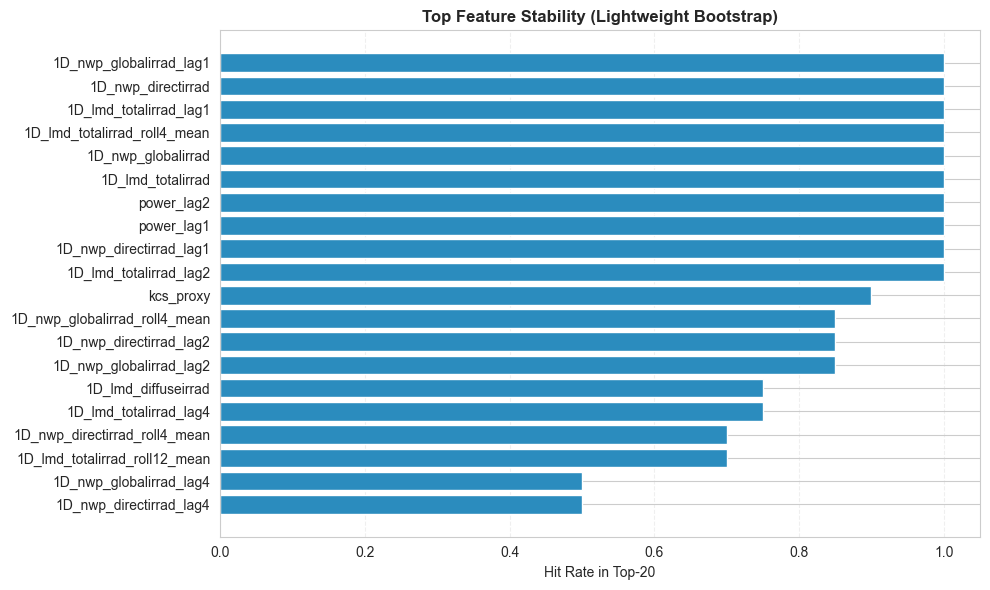


✓ 稳定性结果已保存: /Users/dazhaxie/Desktop/Deye/PVOD_Forecast/artifacts/station05_feature_stability_bootstrap_light.csv


In [14]:
print("=" * 60)
print("增强模块 3/4：Top 特征稳定性（轻量 bootstrap）")
print("=" * 60)

from sklearn.ensemble import RandomForestRegressor

if "df_enhanced" not in globals():
    raise RuntimeError("请先运行增强特征构建单元。")

# 只针对最有解释价值的候选池做稳定性评估，减少计算量同时尽量保持结论不变
all_feature_cols = [c for c in df_enhanced.columns if c != "power"]
priority_cols = []

if "selected_features_union" in globals():
    priority_cols.extend([c for c in selected_features_union if c in all_feature_cols])

priority_cols.extend([c for c in ["sin_hour", "cos_hour", "sin_doy", "cos_doy", "kcs_proxy", "power_lag1", "power_lag2"] if c in all_feature_cols])

temporal_suffixes = ("_lag1", "_lag2", "_lag4", "_lag8", "_roll4_mean", "_roll4_std", "_roll12_mean", "_roll12_std")
priority_cols.extend([c for c in all_feature_cols if c.endswith(temporal_suffixes)])

stability_features = list(dict.fromkeys(priority_cols))

# 兜底：如果候选池过小，就补充前 60 个特征
if len(stability_features) < 20:
    stability_features = all_feature_cols[:min(60, len(all_feature_cols))]

X_stab = df_enhanced[stability_features].replace([np.inf, -np.inf], np.nan).ffill().bfill()
y_stab = df_enhanced["power"]

n_bootstrap = 20
sample_fraction = 0.65
top_k = min(20, X_stab.shape[1])
rng = np.random.default_rng(42)
feature_hit_count = pd.Series(0, index=X_stab.columns, dtype=int)

for b in range(n_bootstrap):
    sample_size = max(int(len(X_stab) * sample_fraction), top_k + 5)
    sample_idx = rng.choice(len(X_stab), size=sample_size, replace=False)
    X_b = X_stab.iloc[sample_idx]
    y_b = y_stab.iloc[sample_idx]

    rf = RandomForestRegressor(
        n_estimators=80,
        max_depth=10,
        max_features="sqrt",
        min_samples_leaf=2,
        random_state=42 + b,
        n_jobs=-1,
    )
    rf.fit(X_b, y_b)
    imp = pd.Series(rf.feature_importances_, index=X_stab.columns).sort_values(ascending=False)
    feature_hit_count.loc[imp.head(top_k).index] += 1

stability_df = pd.DataFrame({
    "Feature": feature_hit_count.index,
    "Hit_Count": feature_hit_count.values,
    "Hit_Rate": feature_hit_count.values / n_bootstrap,
}).sort_values("Hit_Rate", ascending=False).reset_index(drop=True)

print("\n候选稳定性特征池：", len(stability_features))
print("Top 20 稳定特征（bootstrap 命中率）：")
print(stability_df.head(20).round(3).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))
plot_df = stability_df.head(20).sort_values("Hit_Rate", ascending=True)
ax.barh(plot_df["Feature"], plot_df["Hit_Rate"], color="#2b8cbe")
ax.set_xlabel("Hit Rate in Top-20")
ax.set_title("Top Feature Stability (Lightweight Bootstrap)", fontweight="bold")
ax.grid(axis="x", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

stability_path = ARTIFACTS_DIR / "station05_feature_stability_bootstrap_light.csv"
stability_df.to_csv(stability_path, index=False)
print(f"\n✓ 稳定性结果已保存: {stability_path}")

增强模块 4/4：分场景误差分析（按辐照区间）

分场景误差结果：
            scene  Count    MAE   RMSE  MAPE(%)
   Low Irradiance  209.0 0.0324 0.0424      NaN
Medium Irradiance   99.0 0.2654 0.3900      NaN
  High Irradiance  159.0 1.9819 2.6240  25.0622


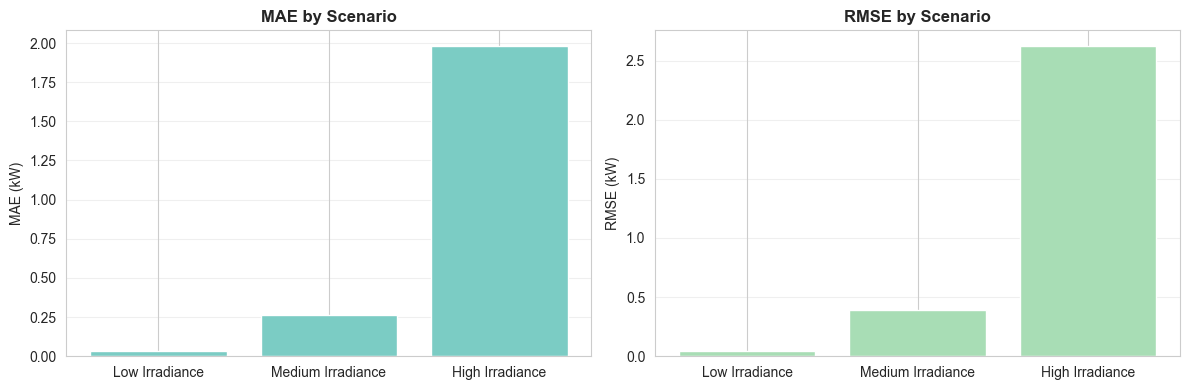


✓ 分场景评估结果已保存: /Users/dazhaxie/Desktop/Deye/PVOD_Forecast/artifacts/station05_enhanced_scene_metrics.csv


In [13]:
print("=" * 60)
print("增强模块 4/4：分场景误差分析（按辐照区间）")
print("=" * 60)

if "enhanced_cv_model" not in globals() or "enhanced_last_test_idx" not in globals():
    raise RuntimeError("请先运行时序交叉验证单元。")

X_all_enh = df_enhanced[[c for c in df_enhanced.columns if c != "power"]].replace([np.inf, -np.inf], np.nan).ffill().bfill()
y_all_enh = df_enhanced["power"]

X_test_last = X_all_enh.iloc[enhanced_last_test_idx]
y_test_last = y_all_enh.iloc[enhanced_last_test_idx]
y_pred_last = enhanced_cv_model.predict(X_test_last)

result_last = pd.DataFrame({
    "y_true": y_test_last.values,
    "y_pred": y_pred_last,
}, index=y_test_last.index)

if "irrad_proxy_col" in globals() and irrad_proxy_col is not None and irrad_proxy_col in df_enhanced.columns:
    result_last["irrad_proxy"] = df_enhanced.loc[result_last.index, irrad_proxy_col]
else:
    result_last["irrad_proxy"] = np.nan

result_last["abs_error"] = (result_last["y_true"] - result_last["y_pred"]).abs()
result_last["sq_error"] = (result_last["y_true"] - result_last["y_pred"]) ** 2

if result_last["irrad_proxy"].notna().sum() > 0:
    q1, q2 = result_last["irrad_proxy"].quantile([0.33, 0.66])
    result_last["scene"] = pd.cut(
        result_last["irrad_proxy"],
        bins=[-np.inf, q1, q2, np.inf],
        labels=["Low Irradiance", "Medium Irradiance", "High Irradiance"],
    )
else:
    result_last["scene"] = "Unknown"

scene_metrics = result_last.groupby("scene").apply(
    lambda g: pd.Series({
        "Count": len(g),
        "MAE": g["abs_error"].mean(),
        "RMSE": np.sqrt(g["sq_error"].mean()),
        "MAPE(%)": np.mean(np.where(g["y_true"].abs() > 1e-6, g["abs_error"] / g["y_true"].abs(), np.nan)) * 100,
    })
).reset_index()

print("\n分场景误差结果：")
print(scene_metrics.round(4).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(scene_metrics["scene"].astype(str), scene_metrics["MAE"], color="#7bccc4")
axes[0].set_title("MAE by Scenario", fontweight="bold")
axes[0].set_ylabel("MAE (kW)")
axes[0].grid(axis="y", alpha=0.3)

axes[1].bar(scene_metrics["scene"].astype(str), scene_metrics["RMSE"], color="#a8ddb5")
axes[1].set_title("RMSE by Scenario", fontweight="bold")
axes[1].set_ylabel("RMSE (kW)")
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

enhanced_artifact_path = ARTIFACTS_DIR / "station05_enhanced_scene_metrics.csv"
scene_metrics.to_csv(enhanced_artifact_path, index=False)
print(f"\n✓ 分场景评估结果已保存: {enhanced_artifact_path}")